# CHEATSHEET — Introducción al Machine Learning (IIND3118)
## Python · listo para usar en el parcial

### Cómo usar este notebook

1. Corre la celda **SETUP** (imports). Una sola vez.
2. Ve a **CARGAR DATOS** y cambia **únicamente el bloque marcado**. Ahí eliges tu archivo y cuál columna es la variable respuesta.
3. Salta al método que necesites por el índice. **Todos los métodos usan los mismos nombres de variables**, así que funcionan sin tocar nada más.

Después de cargar tus datos quedan definidos automáticamente:

| Variable | Qué es |
|---|---|
| `df` | El DataFrame completo |
| `X` | Matriz de predictores (numpy, ya numérica) |
| `y` | Variable respuesta |
| `Xs` | `X` estandarizada (media 0, sd 1) |
| `nombres_X` | Nombres de las columnas de `X` |
| `X_train, X_test, y_train, y_test` | Partición 70/30 |
| `Xs_train, Xs_test` | Lo mismo pero estandarizado |

> **Regla práctica:** si el método usa **distancias** (K-Means, KNN, DBSCAN, PCA, LOF…) usa `Xs`. Si es un **modelo lineal con penalización** (Ridge/Lasso/ElasticNet) también `Xs`. Regresión lineal simple y árboles pueden usar `X`.

---

## ÍNDICE

### Parte A — Aprendizaje SUPERVISADO (clases 10–14)
| | Tema | Cuándo se usa |
|---|---|---|
| [A1](#a1) | Partición train/test y MSE | Siempre, antes de todo |
| [A2](#a2) | Flexibilidad y sesgo–varianza | Concepto base del curso |
| [A3](#a3) | KNN y kernel regression | Modelo flexible no paramétrico |
| [A4](#a4) | Métricas: regresión y clasificación | Evaluar cualquier modelo |
| [A5](#a5) | AIC, BIC, Cp, R² ajustado | Comparar modelos lineales |
| [A6](#a6) | Validación cruzada (k-fold) | Calibrar sin gastar datos |
| [A7](#a7) | Regresión lineal | Modelo base interpretable |
| [A8](#a8) | Selección de variables (forward / exhaustiva) | Muchos predictores |
| [A9](#a9) | Ridge, Lasso, Elastic Net | Multicolinealidad, p grande |
| [A10](#a10) | Comparación final de modelos | Cerrar el análisis |

### Parte B — Aprendizaje NO SUPERVISADO (clases 1–9)
| | Tema | Cuándo se usa |
|---|---|---|
| [B1](#b1) | K-Means | Agrupar, clusters redondos |
| [B2](#b2) | K-Medoides + Gower | Agrupar con outliers o categóricas |
| [B3](#b3) | Clustering jerárquico | Ver la jerarquía, no fijar K |
| [B4](#b4) | DBSCAN | Clusters de forma rara + ruido |
| [B5](#b5) | Métricas de clustering | Elegir K |
| [B6](#b6) | Outliers: Z-Score y Mahalanobis | Pocas dimensiones |
| [B7](#b7) | Outliers: LOF e Isolation Forest | Muchas dimensiones / locales |
| [B8](#b8) | PCA | Reducir dimensión, visualizar |
| [B9](#b9) | MDS | Solo tengo distancias |
| [B10](#b10) | Análisis Factorial | Factores latentes interpretables |
| [B11](#b11) | Kernel PCA | Estructura no lineal |
| [B12](#b12) | SVD | Aproximación de rango bajo |
| [B13](#b13) | Manifold (Isomap, LLE, t-SNE) | Visualizar estructura curva |

[Tabla final: qué método usar según el problema](#final)

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  SETUP — corre esta celda una sola vez
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 90

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, scale
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  RidgeCV, LassoCV, ElasticNetCV, LogisticRegression)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
from sklearn.decomposition import PCA, KernelPCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn import manifold

print("Setup listo.")

Setup listo.


<a id="datos"></a>
---
# ⬇️ CARGAR DATOS — **el único bloque que debes editar**

Elige **una** de las opciones de abajo (descomenta la que uses, comenta las demás) y ajusta el nombre de la columna respuesta en `TARGET`.

- **Opción 1** — CSV propio (lo más común en un parcial)
- **Opción 2** — Excel
- **Opción 3** — Dataset de `sklearn` (para practicar)
- **Opción 4** — Archivo de texto separado por espacios

Si el problema es **no supervisado** (clustering, PCA…), pon `TARGET = None`.

In [2]:
# ╔═════════════════════════════════════════════════════════════════════════╗
# ║  ✏️  CAMBIA SOLO ESTE BLOQUE                                            ║
# ╚═════════════════════════════════════════════════════════════════════════╝

# ── Opción 1: CSV  (la más común) ────────────────────────────────────────
df = pd.read_csv("data/ejemplo_regresion.csv")
TARGET = "target"          # nombre EXACTO de la columna respuesta. None si no hay.

# ── Opción 2: Excel ──────────────────────────────────────────────────────
# df = pd.read_excel("data/mis_datos.xlsx", sheet_name=0)
# TARGET = "y"

# ── Opción 3: dataset de sklearn ─────────────────────────────────────────
# from sklearn.datasets import load_diabetes        # regresión
# from sklearn.datasets import load_wine, load_iris # clasificación
# _d = load_diabetes(as_frame=True); df = _d.frame; TARGET = "target"

# ── Opción 4: texto separado por espacios ────────────────────────────────
# df = pd.read_csv("data/measure.txt", sep=r"\s+")
# TARGET = None

# ╔═════════════════════════════════════════════════════════════════════════╗
# ║  ⬇️  DE AQUÍ PARA ABAJO NO TOQUES NADA                                  ║
# ╚═════════════════════════════════════════════════════════════════════════╝

df = df.dropna()                                   # quita filas con faltantes

if TARGET is not None:
    y_serie = df[TARGET]
    X_df = df.drop(columns=[TARGET])
else:
    y_serie = None
    X_df = df.copy()

# Las columnas de texto se convierten a variables dummy (0/1) automáticamente
X_df = pd.get_dummies(X_df, drop_first=True).astype(float)

nombres_X = list(X_df.columns)
X = X_df.values
Xs = scale(X)                                      # estandarizado: media 0, sd 1

if y_serie is not None:
    # Si y es texto, se codifica a números (0,1,2,...)
    y = pd.factorize(y_serie)[0] if y_serie.dtype == object else y_serie.values
    ES_CLASIFICACION = (len(np.unique(y)) <= 10) and np.all(y == np.round(y))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=0)      # 30% para test
    Xs_train, Xs_test, _, _ = train_test_split(
        Xs, y, test_size=0.30, random_state=0)     # mismos índices (mismo random_state)
else:
    y = None; ES_CLASIFICACION = False
    X_train = X_test = y_train = y_test = Xs_train = Xs_test = None

# ── Resumen de lo que quedó cargado ──────────────────────────────────────
print(f"df           : {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"X            : {X.shape[0]} obs. x {X.shape[1]} predictores")
print(f"predictores  : {nombres_X}")
if y is not None:
    tipo = "CLASIFICACIÓN" if ES_CLASIFICACION else "REGRESIÓN"
    print(f"y ('{TARGET}'): {tipo}   rango [{y.min():.2f}, {y.max():.2f}]")
    print(f"train/test   : {len(y_train)} / {len(y_test)}")
else:
    print("y            : ninguna (problema NO SUPERVISADO)")

# Atajo: devuelve el modelo lineal correcto según el tipo de problema
def ModeloLineal(**kw):
    """LogisticRegression si es clasificación, LinearRegression si es regresión."""
    return (LogisticRegression(max_iter=5000, **kw) if ES_CLASIFICACION
            else LinearRegression(**kw))

df.head()

df           : 442 filas x 11 columnas
X            : 442 obs. x 10 predictores
predictores  : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
y ('target'): REGRESIÓN   rango [25.00, 346.00]
train/test   : 309 / 133


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


<a id="a1"></a>
---
# A1. Partición train / test y el MSE

## Qué hace, en simple

Partes los datos en dos: con una parte **entrenas** el modelo y con la otra **lo calificas**. Es como estudiar con unos ejercicios y presentar el examen con otros distintos: si te calificas con los mismos que estudiaste, la nota no dice nada sobre si aprendiste.

## Por qué es necesario

El error medido en los datos de entrenamiento **siempre baja** si haces el modelo más flexible. Un modelo que memoriza cada punto tiene error de entrenamiento cero y no sirve para nada. El error que importa es el de **test**, sobre datos que el modelo nunca vio.

$$MSE_{test} = \frac{1}{n_{test}}\sum_{i=1}^{n_{test}}(\hat y_i - y_i)^2$$

## Parámetros de `train_test_split`

| Parámetro | Qué poner |
|---|---|
| `test_size` | Fracción para test. **Entre 0.10 y 0.50**; lo típico es `0.30` o `0.33` |
| `random_state` | Cualquier número fijo (ej. `0`). **Ponlo siempre** para que el resultado se repita |
| `stratify=y` | **Solo en clasificación.** Mantiene la proporción de clases en ambas partes |
| `shuffle` | `True` por defecto. Ponlo en `False` solo con series de tiempo |

train: 309 obs.  |  test: 133 obs.

MSE en test : 3097.119
RMSE en test: 55.652   <- en las mismas unidades que y
MSE a mano  : 3097.119


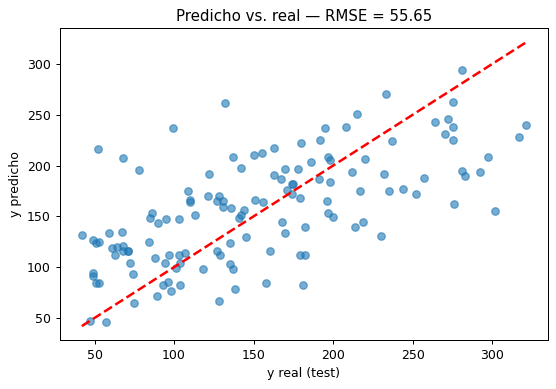

Entre más pegados los puntos a la línea roja, mejor el modelo.


In [3]:
# ═══ A1. Partición train/test ═══

# Ya está hecha arriba, pero así se hace manualmente si necesitas otra:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.30,        # 30% para test
    random_state=0,        # semilla fija -> reproducible
    # stratify=y,          # ⬅ DESCOMENTA si es CLASIFICACIÓN
)
print(f"train: {len(y_tr)} obs.  |  test: {len(y_te)} obs.")

# ── Cómo calcular el MSE de cualquier modelo ────────────────────────────
modelo = ModeloLineal().fit(Xs_train, y_train)      # 1. entrenas con TRAIN
pred = modelo.predict(Xs_test)                      # 2. predices en TEST
mse = mean_squared_error(y_test, pred)              # 3. comparas con el y real

print(f"\nMSE en test : {mse:.3f}")
print(f"RMSE en test: {np.sqrt(mse):.3f}   <- en las mismas unidades que y")

# También a mano, por si piden la fórmula:
print(f"MSE a mano  : {np.mean((pred - y_test)**2):.3f}")

# ── Gráfica estándar: predicho vs. real (solo tiene sentido en regresión) ──
if ES_CLASIFICACION:
    print("\n(En clasificación mira la matriz de confusión, sección A4.)")
plt.scatter(y_test, pred, alpha=.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("y real (test)"); plt.ylabel("y predicho")
plt.title(f"Predicho vs. real — RMSE = {np.sqrt(mse):.2f}")
plt.show()
print("Entre más pegados los puntos a la línea roja, mejor el modelo.")

<a id="a2"></a>
---
# A2. Flexibilidad y el dilema sesgo–varianza

## Qué es, en simple

La **flexibilidad** es cuánto se puede "doblar" el modelo para seguir a los datos.

- **Poca flexibilidad** → el modelo es muy rígido, no captura la forma real. Se equivoca siempre igual. Esto es **SESGO** (*bias*). El modelo *subajusta* (**underfitting**).
- **Mucha flexibilidad** → el modelo persigue hasta el ruido. Con otra muestra daría algo muy distinto. Esto es **VARIANZA**. El modelo *sobreajusta* (**overfitting**).

## La descomposición

$$EPE = \underbrace{\sigma^2}_{\text{error irreducible}} + \underbrace{\text{Sesgo}^2}_{\downarrow \text{ con flexibilidad}} + \underbrace{\text{Varianza}}_{\uparrow \text{ con flexibilidad}}$$

El **error irreducible** $\sigma^2$ es el ruido de los datos: **ningún modelo lo puede eliminar**. Es el piso.

## La forma de las curvas (esto sale en el parcial)

- **MSE de TRAIN**: baja siempre al aumentar flexibilidad. Tiende a 0. **No sirve para calibrar.**
- **MSE de TEST**: tiene forma de **U**. Baja, toca un mínimo, y vuelve a subir.

**El punto óptimo de flexibilidad es el mínimo de la U del MSE de test.**

## Cómo se controla la flexibilidad en cada modelo

| Modelo | Parámetro | Más flexible cuando… |
|---|---|---|
| KNN | `n_neighbors` (k) | **k pequeño** |
| Kernel regression | `h` (ancho de ventana) | **h pequeño** |
| Regresión lineal | número de variables | **más variables** |
| Ridge / Lasso | `alpha` ($\lambda$) | **alpha pequeño** |
| Árbol | profundidad | **más profundo** |

> Ojo con la dirección: en KNN, kernel y Ridge/Lasso, **el parámetro grande = modelo rígido**.

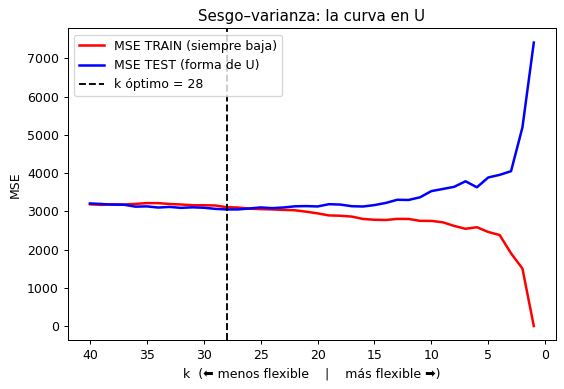

k óptimo             : 28
MSE test en el óptimo: 3050.171

Izquierda (k grande) = mucho SESGO, el modelo es muy rígido.
Derecha  (k pequeño) = mucha VARIANZA, el modelo persigue el ruido.


In [4]:
# ═══ A2. La curva en U del MSE de test ═══
# Se ilustra con KNN variando k. El mismo patrón aplica a cualquier modelo.

# KNN = el regresor o el clasificador, según el problema
KNN = KNeighborsClassifier if ES_CLASIFICACION else KNeighborsRegressor

ks = range(1, 41)
mse_train_list, mse_test_list = [], []

for k in ks:
    m = KNN(n_neighbors=k).fit(Xs_train, y_train)
    mse_train_list.append(mean_squared_error(y_train, m.predict(Xs_train)))
    mse_test_list.append(mean_squared_error(y_test,  m.predict(Xs_test)))

k_opt = list(ks)[int(np.argmin(mse_test_list))]

# ⚠️ El eje x va de k grande a k pequeño para que "flexibilidad" crezca hacia
#    la derecha, como en las diapositivas.
plt.plot(ks, mse_train_list, "r-", lw=2, label="MSE TRAIN (siempre baja)")
plt.plot(ks, mse_test_list,  "b-", lw=2, label="MSE TEST (forma de U)")
plt.axvline(k_opt, color="k", ls="--", label=f"k óptimo = {k_opt}")
plt.gca().invert_xaxis()                      # ⬅ izquierda = rígido, derecha = flexible
plt.xlabel("k  (⬅ menos flexible    |    más flexible ➡)")
plt.ylabel("MSE"); plt.legend(); plt.title("Sesgo–varianza: la curva en U")
plt.show()

print(f"k óptimo             : {k_opt}")
print(f"MSE test en el óptimo: {min(mse_test_list):.3f}")
print("\nIzquierda (k grande) = mucho SESGO, el modelo es muy rígido.")
print("Derecha  (k pequeño) = mucha VARIANZA, el modelo persigue el ruido.")

<a id="a3"></a>
---
# A3. KNN y kernel regression

## KNN (k vecinos más cercanos), en simple

Para predecir un punto nuevo: **busca los k puntos más parecidos** en los datos de entrenamiento y devuelve el **promedio** de sus $y$ (regresión) o la **clase más votada** (clasificación).

No aprende ninguna fórmula: se guarda todos los datos y compara. Por eso se llama método *perezoso*.

## Kernel regression, en simple

Casi igual, pero en vez de "los k más cercanos" usa **todos los que caigan dentro de una ventana de ancho h**:

$$\hat f(X^*) = \frac{\sum_i \mathbb{I}(|X_i - X^*| \leq h)\, Y_i}{\sum_i \mathbb{I}(|X_i - X^*| \leq h)}$$

Diferencia: en KNN el número de vecinos es fijo y la distancia varía; en kernel la distancia es fija y el número de vecinos varía.

## ⚠️ Lo más importante: ESTANDARIZAR

Ambos usan **distancias**. Si una variable está en pesos (millones) y otra en años (decenas), la de pesos domina todo. **Usa siempre `Xs`, no `X`.**

## Parámetros

| Parámetro | Qué poner |
|---|---|
| `n_neighbors` (k) | El parámetro a calibrar. Empieza probando 1 a 40. **k pequeño = flexible** |
| `weights` | `'uniform'` (todos pesan igual) o `'distance'` (los más cercanos pesan más) |
| `metric` | `'minkowski'` con `p=2` es euclidiana (por defecto); `p=1` es Manhattan |

## Ventajas
- Muy simple, sin supuestos sobre la forma de la relación
- Captura relaciones no lineales automáticamente

## Desventajas
- **Hay que estandarizar sí o sí**
- Lento al predecir (compara contra todos los datos)
- **Falla en dimensión alta** (maldición de la dimensionalidad: en muchas dimensiones "cerca" deja de significar algo)
- No da un modelo interpretable: no hay coeficientes

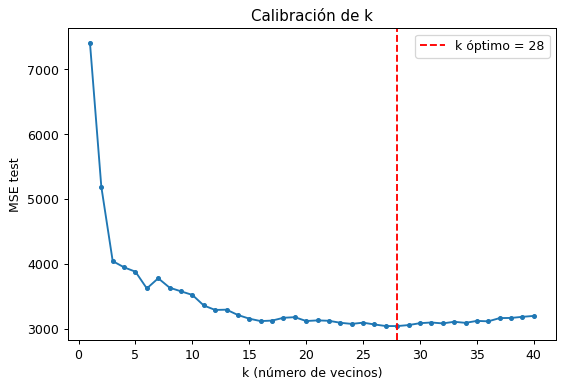

k óptimo = 28   |   MSE test = 3050.171


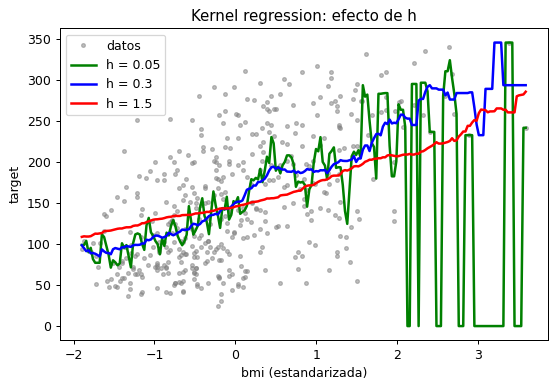

h chico (verde) = persigue el ruido -> VARIANZA
h grande (rojo) = casi una recta plana -> SESGO


In [5]:
# ═══ A3. KNN — calibrar k y evaluar ═══
# ⚠️ SIEMPRE con Xs (estandarizado), porque usa distancias.

Modelo = KNeighborsClassifier if ES_CLASIFICACION else KNeighborsRegressor

# --- 1. Calibrar k con la curva de test ---------------------------------
ks = range(1, 41)
errores = []
for k in ks:
    m = Modelo(n_neighbors=k).fit(Xs_train, y_train)
    p = m.predict(Xs_test)
    errores.append(1 - accuracy_score(y_test, p) if ES_CLASIFICACION
                   else mean_squared_error(y_test, p))

k_opt = list(ks)[int(np.argmin(errores))]

plt.plot(ks, errores, "o-", ms=3)
plt.axvline(k_opt, color="red", ls="--", label=f"k óptimo = {k_opt}")
plt.xlabel("k (número de vecinos)")
plt.ylabel("error de clasificación" if ES_CLASIFICACION else "MSE test")
plt.title("Calibración de k"); plt.legend(); plt.show()

# --- 2. Modelo final con el k calibrado ---------------------------------
knn = Modelo(
    n_neighbors=k_opt,      # ⬅ el k que calibraste
    weights="uniform",      # 'uniform' o 'distance'
).fit(Xs_train, y_train)

pred_knn = knn.predict(Xs_test)
mse_knn = mean_squared_error(y_test, pred_knn)
print(f"k óptimo = {k_opt}   |   MSE test = {mse_knn:.3f}")


# ═══ Kernel regression (ventana h) — implementación de clase ═══
def kernelreg(xstar, X_, Y_, h):
    """Promedio de los Y cuyos X caen dentro de [xstar-h, xstar+h].
       h GRANDE = modelo rígido (mucho sesgo). h PEQUEÑO = flexible."""
    pred = np.zeros(len(xstar))
    for i in range(len(xstar)):
        dentro = np.abs(xstar[i] - X_) <= h
        pred[i] = np.sum(np.where(dentro, Y_, 0)) / max(dentro.sum(), 1)
    return pred

# Demostración en 1 variable (la de mayor correlación con y)
j = int(np.argmax([abs(np.corrcoef(X[:, c], y)[0, 1]) for c in range(X.shape[1])]))
x1 = Xs[:, j]
orden = np.argsort(x1)
malla = np.linspace(x1.min(), x1.max(), 200)

plt.plot(x1, y, "o", ms=3, color="gray", alpha=.5, label="datos")
for h, col in [(0.05, "green"), (0.3, "blue"), (1.5, "red")]:
    plt.plot(malla, kernelreg(malla, x1, y, h), col, lw=2, label=f"h = {h}")
plt.xlabel(f"{nombres_X[j]} (estandarizada)"); plt.ylabel(TARGET)
plt.title("Kernel regression: efecto de h"); plt.legend(); plt.show()

print("h chico (verde) = persigue el ruido -> VARIANZA")
print("h grande (rojo) = casi una recta plana -> SESGO")

<a id="a4"></a>
---
# A4. Métricas de evaluación

## REGRESIÓN

| Métrica | Fórmula | Cómo se lee |
|---|---|---|
| **MSE** | $\frac{1}{n}\sum(\hat y_i - y_i)^2$ | El estándar. **Minimizar.** Castiga mucho los errores grandes |
| **RMSE** | $\sqrt{MSE}$ | Igual que MSE pero **en las unidades de $y$**. Más fácil de interpretar |
| **MAE** | $\frac{1}{n}\sum\lvert\hat y_i - y_i\rvert$ | Más **robusto a outliers** que el MSE |
| **MAPE** | $\frac{100}{n}\sum\lvert\frac{\hat y_i - y_i}{y_i}\rvert$ | Error en **%**. No sirve si $y$ puede ser 0 |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | % de varianza explicada. **Maximizar.** Entre 0 y 1 |

## CLASIFICACIÓN

La **matriz de confusión** es la base de todo:

| | Predicho 0 | Predicho 1 |
|---|---|---|
| **Real 0** | TN (verdadero negativo) | FP (falso positivo) |
| **Real 1** | FN (falso negativo) | TP (verdadero positivo) |

| Métrica | Fórmula | Cuándo importa |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{\text{total}}$ | Métrica general. **Engaña si las clases están desbalanceadas** |
| **Sensibilidad / Recall** | $\frac{TP}{TP+FN}$ | De los que **sí** eran, ¿cuántos detecté? Clave en diagnóstico médico y fraude |
| **Especificidad** | $\frac{TN}{TN+FP}$ | De los que **no** eran, ¿cuántos descarté bien? |
| **Precisión** | $\frac{TP}{TP+FP}$ | De los que **predije** positivos, ¿cuántos acerté? |
| **F1** | media armónica de precisión y recall | Balance entre las dos |
| **AUC-ROC** | área bajo la curva ROC | Calidad global sin fijar umbral. 0.5 = azar, 1 = perfecto |

> ⚠️ **La trampa del accuracy:** si el 99% de los datos son clase 0, un modelo que siempre dice "0" tiene 99% de accuracy y es inútil. Mira siempre la matriz de confusión.

── Regresión lineal ──
MSE  : 3097.1192
RMSE : 55.6518   (unidades de y)
MAE  : 44.6176   (robusto a outliers)
R²   : 0.3929   (% de varianza explicada)
MAPE : 39.54%


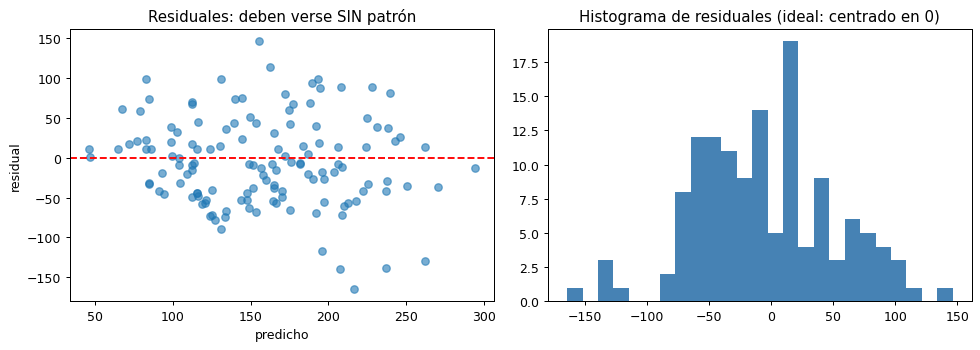

In [6]:
# ═══ A4. Todas las métricas de un modelo ═══

def evaluar(y_real, y_pred, nombre="modelo"):
    """Imprime las métricas correctas según el tipo de problema."""
    print(f"── {nombre} ──")
    if ES_CLASIFICACION:
        cm = confusion_matrix(y_real, y_pred)
        print(f"Accuracy : {accuracy_score(y_real, y_pred):.4f}")
        print("\nMatriz de confusión (filas = real, columnas = predicho):")
        print(cm)
        if cm.shape == (2, 2):                      # métricas binarias
            tn, fp, fn, tp = cm.ravel()
            print(f"\nSensibilidad (recall): {tp/(tp+fn):.4f}  <- de los SÍ, cuántos detecté")
            print(f"Especificidad       : {tn/(tn+fp):.4f}  <- de los NO, cuántos descarté")
            print(f"Precisión           : {tp/(tp+fp):.4f}  <- de mis SÍ, cuántos acerté")
        print("\n", classification_report(y_real, y_pred, zero_division=0))
    else:
        mse = mean_squared_error(y_real, y_pred)
        print(f"MSE  : {mse:.4f}")
        print(f"RMSE : {np.sqrt(mse):.4f}   (unidades de y)")
        print(f"MAE  : {mean_absolute_error(y_real, y_pred):.4f}   (robusto a outliers)")
        print(f"R²   : {r2_score(y_real, y_pred):.4f}   (% de varianza explicada)")
        if np.all(y_real != 0):
            print(f"MAPE : {np.mean(np.abs((y_pred-y_real)/y_real))*100:.2f}%")
    return None

modelo = ModeloLineal().fit(Xs_train, y_train)
nombre_mod = "Regresión logística" if ES_CLASIFICACION else "Regresión lineal"
evaluar(y_test, modelo.predict(Xs_test), nombre_mod)

# ── Gráfica de residuales (solo regresión) ──────────────────────────────
if not ES_CLASIFICACION:
    pred = modelo.predict(Xs_test)
    resid = y_test - pred
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].scatter(pred, resid, alpha=.6); ax[0].axhline(0, color="red", ls="--")
    ax[0].set_xlabel("predicho"); ax[0].set_ylabel("residual")
    ax[0].set_title("Residuales: deben verse SIN patrón")
    ax[1].hist(resid, bins=25, color="steelblue")
    ax[1].set_title("Histograma de residuales (ideal: centrado en 0)")
    plt.tight_layout(); plt.show()

# ── Curva ROC (solo clasificación binaria) ──────────────────────────────
if ES_CLASIFICACION and len(np.unique(y)) == 2:
    clf = LogisticRegression(max_iter=2000).fit(Xs_train, y_train)
    proba = clf.predict_proba(Xs_test)[:, 1]        # probabilidad de la clase 1
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], "r--", label="azar (AUC = 0.5)")
    plt.xlabel("1 - Especificidad (FPR)"); plt.ylabel("Sensibilidad (TPR)")
    plt.title("Curva ROC"); plt.legend(); plt.show()

<a id="a5"></a>
---
# A5. AIC, BIC, Cp de Mallows y R² ajustado

## El problema que resuelven

Si agregas variables a una regresión, el **R² siempre sube** y el **MSE de train siempre baja**, aunque las variables sean basura. Necesitas una métrica que **castigue la complejidad**.

Estas cuatro métricas hacen exactamente eso: miden el ajuste **y le restan un castigo** por cada parámetro extra. Son una alternativa al MSE de test cuando no quieres (o no puedes) partir la muestra.

## Las fórmulas

| Métrica | Fórmula | Dirección |
|---|---|---|
| **R² ajustado** | $1 - \frac{(1-R^2)(n-1)}{n-p-1}$ | **Maximizar** |
| **AIC** | $-2\log L + 2p$ | **Minimizar** |
| **BIC** | $-2\log L + p\log n$ | **Minimizar** |
| **Cp de Mallows** | $\frac{1}{n}(SSE + 2p\hat\sigma^2)$ | **Minimizar** |

donde $p$ = número de parámetros y $n$ = número de observaciones.

## AIC vs. BIC — la diferencia que preguntan

El castigo del BIC es $p\log n$; el del AIC es $2p$. Como $\log n > 2$ siempre que $n > 7$:

> **El BIC castiga más fuerte la complejidad que el AIC.** Por eso el BIC tiende a elegir **modelos más pequeños** (menos variables) que el AIC.

- **AIC**: busca el modelo que mejor predice
- **BIC**: busca el modelo "verdadero", es más conservador

primeras 1 variables         p= 1  R²adj= 0.0303  AIC=  3572.95  BIC=  3580.42  Cp=  6115.80
primeras 2 variables         p= 2  R²adj= 0.0279  AIC=  3574.69  BIC=  3585.89  Cp=  6150.44
primeras 3 variables         p= 3  R²adj= 0.3794  AIC=  3437.01  BIC=  3451.94  Cp=  3939.16
primeras 4 variables         p= 4  R²adj= 0.4196  AIC=  3417.32  BIC=  3435.99  Cp=  3696.11
primeras 5 variables         p= 5  R²adj= 0.4182  AIC=  3419.02  BIC=  3441.42  Cp=  3716.58
primeras 6 variables         p= 6  R²adj= 0.4204  AIC=  3418.86  BIC=  3445.00  Cp=  3714.76
primeras 7 variables         p= 7  R²adj= 0.5222  AIC=  3360.12  BIC=  3389.98  Cp=  3071.64
primeras 8 variables         p= 8  R²adj= 0.5207  AIC=  3362.11  BIC=  3395.71  Cp=  3091.64
primeras 9 variables         p= 9  R²adj= 0.5403  AIC=  3350.14  BIC=  3387.47  Cp=  2974.19
primeras 10 variables        p=10  R²adj= 0.5390  AIC=  3352.01  BIC=  3393.08  Cp=  2992.34


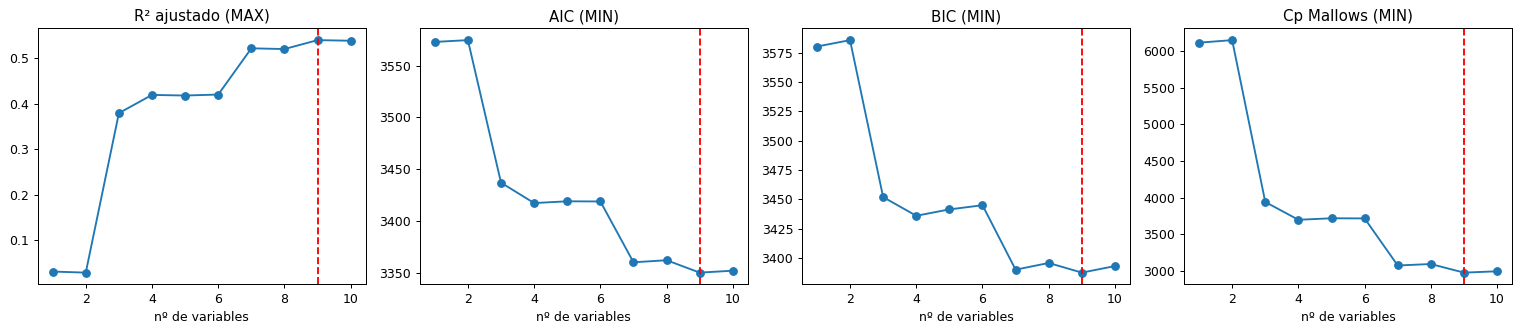


Mejor según R²adj: 9 variables
Mejor según AIC  : 9 variables
Mejor según BIC  : 9 variables  <- suele elegir MENOS
Mejor según Cp   : 9 variables

BIC castiga más la complejidad (p·log n) que AIC (2p).


In [7]:
# ═══ A5. AIC, BIC, Cp y R² ajustado ═══
import statsmodels.api as sm

def criterios(X_, y_, nombre=""):
    """Calcula las 4 métricas de un modelo lineal. X_ sin columna de unos."""
    n, p = X_.shape
    Xc = sm.add_constant(X_)                   # statsmodels necesita el intercepto
    mod = sm.OLS(y_, Xc).fit()
    sse = np.sum(mod.resid ** 2)
    sigma2 = sse / (n - p - 1)
    cp = (sse + 2 * p * sigma2) / n
    print(f"{nombre:28s} p={p:2d}  R²adj={mod.rsquared_adj:7.4f}  "
          f"AIC={mod.aic:9.2f}  BIC={mod.bic:9.2f}  Cp={cp:9.2f}")
    return dict(p=p, r2adj=mod.rsquared_adj, aic=mod.aic, bic=mod.bic, cp=cp)

# Comparar modelos con 1, 2, ..., p variables (las primeras columnas)
res = [criterios(X_train[:, :k], y_train, f"primeras {k} variables")
       for k in range(1, X_train.shape[1] + 1)]

r2a = [r["r2adj"] for r in res]; aic = [r["aic"] for r in res]
bic = [r["bic"] for r in res];   cp  = [r["cp"] for r in res]
ks = range(1, len(res) + 1)

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, v, t, mejor in [(ax[0], r2a, "R² ajustado (MAX)", np.argmax(r2a)),
                       (ax[1], aic, "AIC (MIN)",         np.argmin(aic)),
                       (ax[2], bic, "BIC (MIN)",         np.argmin(bic)),
                       (ax[3], cp,  "Cp Mallows (MIN)",  np.argmin(cp))]:
    a.plot(ks, v, "o-"); a.axvline(list(ks)[mejor], color="red", ls="--")
    a.set_xlabel("nº de variables"); a.set_title(t)
plt.tight_layout(); plt.show()

print(f"\nMejor según R²adj: {np.argmax(r2a)+1} variables")
print(f"Mejor según AIC  : {np.argmin(aic)+1} variables")
print(f"Mejor según BIC  : {np.argmin(bic)+1} variables  <- suele elegir MENOS")
print(f"Mejor según Cp   : {np.argmin(cp)+1} variables")
print("\nBIC castiga más la complejidad (p·log n) que AIC (2p).")

<a id="a6"></a>
---
# A6. Validación cruzada (k-fold)

## Qué hace, en simple

Partir en train/test una sola vez tiene un problema: **el resultado depende de qué datos cayeron en test por azar**. Con mala suerte te toca una partición rara y evalúas mal el modelo.

La validación cruzada arregla eso: parte los datos en **k pedazos (folds)**. Entrena k veces; en cada una deja un pedazo distinto fuera para evaluar. Al final **promedia los k errores**.

Así **todos los datos sirven para entrenar y todos sirven para evaluar**, solo que en rondas distintas.

## El procedimiento con k=5

```
Ronda 1:  [TEST] [train][train][train][train]
Ronda 2:  [train][TEST] [train][train][train]
Ronda 3:  [train][train][TEST] [train][train]
Ronda 4:  [train][train][train][TEST] [train]
Ronda 5:  [train][train][train][train][TEST]
                  ↓
        MSE_CV = promedio de los 5 MSE
```

## Parámetros

| Parámetro | Qué poner |
|---|---|
| `cv` / `n_splits` (k) | **5 o 10** son los estándar. k grande = menos sesgo pero más lento |
| `scoring` | `'neg_mean_squared_error'` (regresión) · `'accuracy'` o `'roc_auc'` (clasificación). **Ojo: sklearn devuelve el MSE en negativo** porque siempre maximiza |
| `shuffle=True` | Mezcla antes de partir. **Ponlo**, salvo en series de tiempo |
| `StratifiedKFold` | Úsalo en clasificación: mantiene la proporción de clases en cada fold |

## Casos especiales
- **LOOCV** (*leave-one-out*): k = n. Cada fold es una sola observación. Sin sesgo pero muy lento y con alta varianza
- **`GridSearchCV`**: hace CV automáticamente probando todas las combinaciones de parámetros. Es lo que usarás en la práctica

## Ventajas / desventajas
- ✅ Usa todos los datos, resultado más estable, no depende de una partición con suerte
- ❌ **k veces más lento**; con series de tiempo no se puede usar así (hay que usar `TimeSeriesSplit`)

MSE de cada uno de los 10 folds:
[3660.57 2995.04 4571.95 3455.58 3762.91 3716.53 4464.45 2826.35 5232.41
 2961.6 ]

MSE promedio (CV): 3764.739  ±  743.103
La desviación indica qué tan estable es el resultado entre folds.

MSE promedio (bucle manual): 3561.414


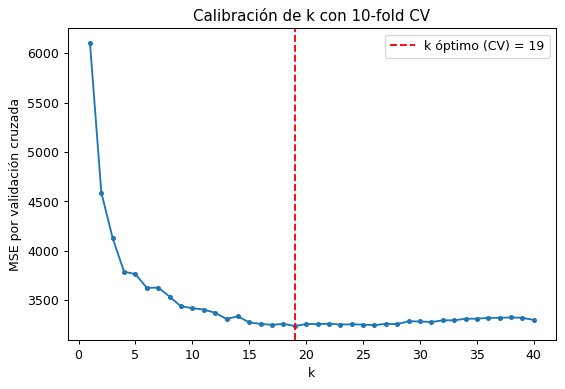

k óptimo por CV = 19   (MSE = 3238.915)



GridSearchCV -> mejores parámetros: {'n_neighbors': 26, 'weights': 'distance'}
MSE del mejor modelo: 3235.522


In [8]:
# ═══ A6. Validación cruzada ═══

# ── Forma 1: la más rápida, cross_val_score ──────────────────────────────
modelo = KNeighborsRegressor(n_neighbors=5)

scores = cross_val_score(
    modelo, Xs, y,
    cv=10,                                  # ⬅ número de folds (5 o 10)
    scoring="neg_mean_squared_error",       # ⬅ OJO: negativo, hay que voltearlo
)
mse_cv = -scores                            # volteamos el signo

print(f"MSE de cada uno de los 10 folds:\n{np.round(mse_cv, 2)}")
print(f"\nMSE promedio (CV): {mse_cv.mean():.3f}  ±  {mse_cv.std():.3f}")
print("La desviación indica qué tan estable es el resultado entre folds.")

# ── Forma 2: el bucle manual, por si piden mostrar el procedimiento ─────
kf = KFold(n_splits=10, shuffle=True, random_state=0)
errores = []
for idx_train, idx_test in kf.split(Xs):
    m = KNeighborsRegressor(n_neighbors=5).fit(Xs[idx_train], y[idx_train])
    errores.append(mean_squared_error(y[idx_test], m.predict(Xs[idx_test])))
print(f"\nMSE promedio (bucle manual): {np.mean(errores):.3f}")

# ── Forma 3: calibrar un parámetro CON validación cruzada ───────────────
ks = range(1, 41)
mse_por_k = [-cross_val_score(KNeighborsRegressor(n_neighbors=k), Xs, y,
                              cv=10, scoring="neg_mean_squared_error").mean()
             for k in ks]
k_cv = list(ks)[int(np.argmin(mse_por_k))]

plt.plot(ks, mse_por_k, "o-", ms=3)
plt.axvline(k_cv, color="red", ls="--", label=f"k óptimo (CV) = {k_cv}")
plt.xlabel("k"); plt.ylabel("MSE por validación cruzada")
plt.title("Calibración de k con 10-fold CV"); plt.legend(); plt.show()
print(f"k óptimo por CV = {k_cv}   (MSE = {min(mse_por_k):.3f})")

# ── Forma 4: GridSearchCV, lo más práctico ─────────────────────────────
grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid={"n_neighbors": range(1, 41),         # ⬅ valores a probar
                "weights": ["uniform", "distance"]},  # ⬅ puede probar varios a la vez
    cv=10,
    scoring="neg_mean_squared_error",
).fit(Xs, y)

print(f"\nGridSearchCV -> mejores parámetros: {grid.best_params_}")
print(f"MSE del mejor modelo: {-grid.best_score_:.3f}")

<a id="a7"></a>
---
# A7. Regresión lineal

## Qué hace, en simple

Busca la **recta (o plano) que mejor pasa por los datos**, minimizando la suma de los errores al cuadrado:

$$\hat\beta = \arg\min \sum_{i=1}^n (Y_i - \beta^t X_i)^2$$

## Cómo se interpretan los coeficientes (esto siempre lo preguntan)

> **Si $X_j$ aumenta una unidad, el valor esperado de $Y$ cambia en $\beta_j$ unidades, manteniendo todas las demás variables constantes.**

Esa última parte ("manteniendo las demás constantes") es lo que hace la interpretación *ceteris paribus* y es la gran ventaja del modelo frente a KNN o un árbol.

## Ventajas
- **El más interpretable de todos**: cada coeficiente tiene significado directo
- Rápido, solución cerrada, sin parámetros que calibrar
- Da errores estándar, valores p e intervalos de confianza
- Es el punto de partida obligado: si un modelo complejo no le gana, no vale la pena

## Desventajas
- **Solo captura relaciones lineales**
- **Sensible a outliers** (los errores van al cuadrado)
- **Sufre con multicolinealidad**: si dos variables están muy correlacionadas, los coeficientes se vuelven inestables y enormes → esto es justo lo que arreglan Ridge/Lasso
- Si $p > n$ no tiene solución única
- Poca flexibilidad: sesgo alto si la relación real es curva

## Supuestos (por si los piden)
Linealidad · errores independientes · varianza constante (homocedasticidad) · errores normales (solo para los valores p)

Intercepto (β₀): 153.7190

variable  coeficiente     |coef|
      s5   721.920838 721.920838
     bmi   579.491085 579.491085
      s1  -504.648304 504.648304
      bp   272.453666 272.453666
      s2   241.623730 241.623730
     sex  -193.507334 193.507334
      s4    86.613140  86.613140
      s3   -69.765960  69.765960
     age   -52.464785  52.464785
      s6    26.780674  26.780674

Lectura: si la variable sube 1 unidad, y cambia en 'coeficiente'
unidades, MANTENIENDO LAS DEMÁS CONSTANTES.

MSE test: 3097.119   |   R² test: 0.3929


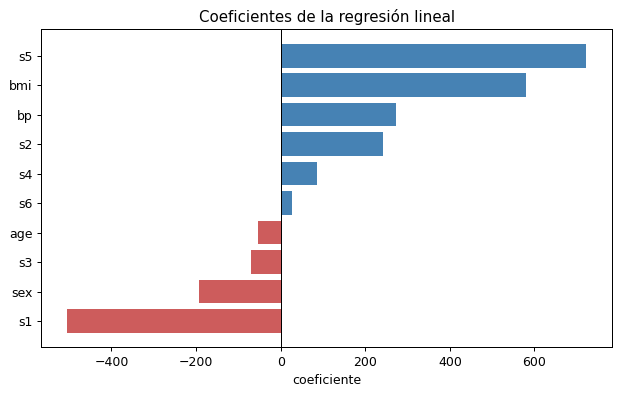

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        153.7190      3.076     49.970      0.000     147.665     159.773
x1           -52.4648     71.260     -0.736      0.462    -192.700      87.771
x2          -193.5073     71.998     -2.688      0.008    -335.196     -51.819
x3           579.4911     79.662      7.274      0.000     422.720     736.262
x4           272.4537     81.194      3.356      0.001     112.668     432.239
x5          -504.6483    485.936     -1.039      0.300   -1460.950     451.653
x6           241.6237    388.679      0.622      0.535    -523.280    1006.528
x7           -69.7660    253.872     -0.275      0.784    -569.374     429.842
x8            86.6131    193.055      0.449      0.654    -293.310     466.536
x9           721.9208    197.026      3.664      0.000     334.183    1109.658
x10           26.7807     76.109      0.352      0.7

In [9]:
# ═══ A7. Regresión lineal ═══

reg = LinearRegression(   # ⬅ para clasificación usa LogisticRegression
    
    fit_intercept=True,     # ⬅ True casi siempre (incluye el β₀)
).fit(X_train, y_train)

# ── Coeficientes ordenados por magnitud ─────────────────────────────────
coefs = pd.DataFrame({"variable": nombres_X, "coeficiente": reg.coef_})
coefs["|coef|"] = coefs["coeficiente"].abs()
print(f"Intercepto (β₀): {reg.intercept_:.4f}\n")
print(coefs.sort_values("|coef|", ascending=False).to_string(index=False))
print("\nLectura: si la variable sube 1 unidad, y cambia en 'coeficiente'")
print("unidades, MANTENIENDO LAS DEMÁS CONSTANTES.")

pred_lm = reg.predict(X_test)
mse_lm = mean_squared_error(y_test, pred_lm)
print(f"\nMSE test: {mse_lm:.3f}   |   R² test: {r2_score(y_test, pred_lm):.4f}")

# ── Gráfica de coeficientes ─────────────────────────────────────────────
c = coefs.sort_values("coeficiente")
plt.barh(c["variable"], c["coeficiente"], color=np.where(c["coeficiente"]>0, "steelblue", "indianred"))
plt.axvline(0, color="k", lw=.8)
plt.xlabel("coeficiente"); plt.title("Coeficientes de la regresión lineal")
plt.tight_layout(); plt.show()

# ── Tabla completa con valores p (statsmodels) ──────────────────────────
import statsmodels.api as sm
ols = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(ols.summary().tables[1])
print("\nP>|t| < 0.05  ->  la variable es estadísticamente significativa.")

# ── Diagnóstico de multicolinealidad (VIF) ─────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xc = sm.add_constant(X_train)
vif = pd.DataFrame({
    "variable": ["const"] + nombres_X,
    "VIF": [variance_inflation_factor(Xc, i) for i in range(Xc.shape[1])]
})
print("\n", vif[vif.variable != "const"].sort_values("VIF", ascending=False).to_string(index=False))
print("VIF > 10  ->  multicolinealidad seria. Usa Ridge/Lasso (tema A9).")

<a id="a8"></a>
---
# A8. Selección de variables

## El problema

Con $p$ variables hay $2^p - 1$ modelos posibles. Con 20 variables son más de un millón. ¿Cuál conjunto usar?

Meter todas no es la respuesta: variables irrelevantes **agregan varianza sin agregar señal**, y hacen el modelo menos interpretable.

## Método exhaustivo

Prueba **todos** los $2^p - 1$ modelos y se queda con el mejor.

- ✅ **Garantiza encontrar el mejor** conjunto bajo la métrica elegida
- ❌ **Crece exponencialmente**: imposible más allá de ~20 variables

## Método forward (hacia adelante)

1. Empieza sin ninguna variable
2. Agrega la que **más mejore** el modelo
3. Repite, dejando fijas las ya escogidas
4. Para cuando ninguna mejora

Compara solo $\frac{p(p+1)}{2}$ modelos: con 20 variables son 210, no un millón.

- ✅ Mucho más rápido, sirve con $p$ grande
- ❌ **Es una heurística: NO garantiza el mejor modelo.** Una variable escogida al principio nunca se vuelve a quitar, aunque deje de ser útil

## Método backward (hacia atrás)

Al revés: empieza con todas y va **quitando** la menos útil. Requiere $n > p$.

## Comparación

| | Exhaustivo | Forward | Backward |
|---|---|---|---|
| Modelos evaluados | $2^p - 1$ | $p(p+1)/2$ | $p(p+1)/2$ |
| Garantiza el óptimo | **Sí** | No | No |
| Sirve con $p$ grande | No | **Sí** | Necesita $n>p$ |

## Parámetros

| Parámetro | Qué poner |
|---|---|
| `n_features_to_select` | Cuántas variables quedarse. `'auto'` deja que decida |
| `direction` | `'forward'` o `'backward'` |
| `scoring` | `'neg_mean_squared_error'`, `'r2'`, `'accuracy'`… |
| `cv` | Folds para evaluar cada candidato. 5 está bien |

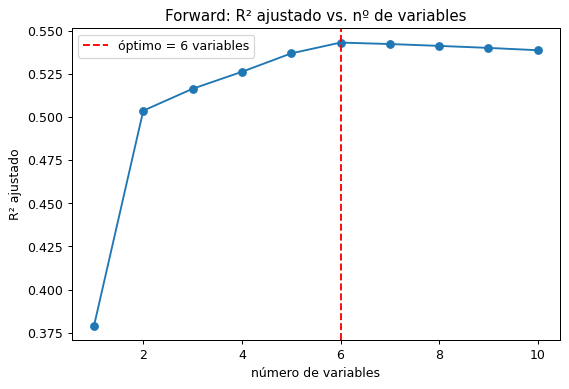

Variables seleccionadas (6): ['sex', 'bmi', 'bp', 's1', 's3', 's5']
MSE test (forward): 3126.016



Variables seleccionadas (6): ['sex', 'bmi', 'bp', 's1', 's2', 's5']
MSE test (exhaustivo): 3083.628


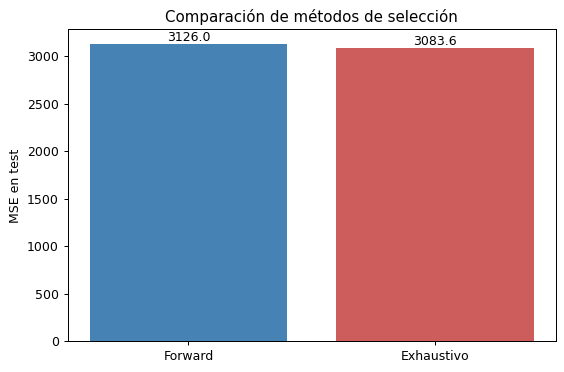

In [10]:
# ═══ A8. Selección de variables ═══
from sklearn.feature_selection import SequentialFeatureSelector

p = X_train.shape[1]

# ── MÉTODO FORWARD: probar cada número de variables y elegir por R² ajustado ──
r2adj = []
n_tr = len(y_train)
for k in range(1, p + 1):
    if k < p:
        sfs = SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select=k,     # ⬅ cuántas variables en esta iteración
            direction="forward",        # ⬅ 'forward' o 'backward'
            cv=5,
        ).fit(X_train, y_train)
        Xk = X_train[:, sfs.get_support()]
    else:
        Xk = X_train
    r2 = LinearRegression().fit(Xk, y_train).score(Xk, y_train)
    r2adj.append(1 - (1 - r2) * (n_tr - 1) / (n_tr - k - 1))   # R² ajustado

k_opt = int(np.argmax(r2adj)) + 1

plt.plot(range(1, p + 1), r2adj, "o-")
plt.axvline(k_opt, color="red", ls="--", label=f"óptimo = {k_opt} variables")
plt.xlabel("número de variables"); plt.ylabel("R² ajustado")
plt.title("Forward: R² ajustado vs. nº de variables"); plt.legend(); plt.show()

# Modelo final con las variables seleccionadas
if k_opt < p:
    sfs_final = SequentialFeatureSelector(LinearRegression(),
                    n_features_to_select=k_opt, direction="forward", cv=5).fit(X_train, y_train)
    mask = sfs_final.get_support()
else:
    mask = np.ones(p, dtype=bool)

vars_fwd = [nombres_X[i] for i in range(p) if mask[i]]
modelo_fwd = LinearRegression().fit(X_train[:, mask], y_train)
mse_fwd = mean_squared_error(y_test, modelo_fwd.predict(X_test[:, mask]))

print(f"Variables seleccionadas ({k_opt}): {vars_fwd}")
print(f"MSE test (forward): {mse_fwd:.3f}")

# ── MÉTODO EXHAUSTIVO ───────────────────────────────────────────────────
# ⚠️ Solo si p es pequeño (<= 15). Con más, tarda demasiado.
if p <= 15:
    from mlxtend.feature_selection import ExhaustiveFeatureSelector
    efs = ExhaustiveFeatureSelector(
        LinearRegression(),
        min_features=1, max_features=p,        # ⬅ rango de tamaños a explorar
        scoring="neg_mean_squared_error",
        cv=5, print_progress=False,
    ).fit(X_train, y_train)

    idx_exh = list(efs.best_idx_)
    vars_exh = [nombres_X[i] for i in idx_exh]
    modelo_exh = LinearRegression().fit(X_train[:, idx_exh], y_train)
    mse_exh = mean_squared_error(y_test, modelo_exh.predict(X_test[:, idx_exh]))
    print(f"\nVariables seleccionadas ({len(idx_exh)}): {vars_exh}")
    print(f"MSE test (exhaustivo): {mse_exh:.3f}")

    plt.bar(["Forward", "Exhaustivo"], [mse_fwd, mse_exh], color=["steelblue","indianred"])
    plt.ylabel("MSE en test"); plt.title("Comparación de métodos de selección")
    for i, v in enumerate([mse_fwd, mse_exh]):
        plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
    plt.show()
else:
    print(f"\np = {p} es demasiado grande para el método exhaustivo (2^{p}-1 modelos).")

<a id="a9"></a>
---
# A9. Regularización: Ridge, Lasso y Elastic Net

## Qué hacen, en simple

La regresión normal solo minimiza el error. Estas versiones minimizan **el error MÁS un castigo por tener coeficientes grandes**:

$$\hat\beta = \arg\min \underbrace{\sum_i (Y_i - \beta^tX_i)^2}_{\text{error}} + \underbrace{\lambda \cdot \text{castigo}(\beta)}_{\text{penalización}}$$

La idea: si un coeficiente es enorme, el modelo probablemente está sobreajustando. **Encogiendo los coeficientes hacia cero se gana estabilidad**, a cambio de un poquito de sesgo.

## Las tres variantes

| Modelo | Castigo | Efecto sobre los coeficientes |
|---|---|---|
| **Ridge** (norma 2) | $\lambda\sum\beta_j^2$ | Los **encoge** hacia 0, pero **nunca los deja en 0 exacto**. Se quedan todas las variables |
| **Lasso** (norma 1) | $\lambda\sum\lvert\beta_j\rvert$ | Puede dejar coeficientes **exactamente en 0** → **selecciona variables automáticamente** |
| **Elastic Net** | $\lambda[(1-\alpha)\sum\beta_j^2 + \alpha\sum\lvert\beta_j\rvert]$ | Mezcla de los dos |

> **La diferencia clave que preguntan:** Lasso hace **selección de variables** (pone ceros); Ridge no, solo encoge.

En Elastic Net: $\alpha = 0$ → es Ridge · $\alpha = 1$ → es Lasso · $0 < \alpha < 1$ → mezcla.

## El parámetro $\lambda$ (`alpha` en sklearn)

| Valor | Efecto |
|---|---|
| $\lambda = 0$ | No hay castigo → es la regresión lineal normal |
| $\lambda$ pequeño | Poco castigo → modelo flexible |
| $\lambda$ grande | Mucho castigo → todos los coeficientes tienden a 0 → modelo rígido |
| $\lambda \to \infty$ | Todos los coeficientes en 0, el modelo predice la media |

**Se calibra con validación cruzada**, usando `RidgeCV`, `LassoCV` o `ElasticNetCV`.

## ⚠️ ESTANDARIZAR ES OBLIGATORIO

El castigo suma los coeficientes. Si una variable está en pesos y otra en años, sus coeficientes están en escalas distintas y el castigo las trata injustamente. **Usa siempre `Xs`.**

## Cuándo usar cuál

| Situación | Modelo |
|---|---|
| Muchas variables correlacionadas entre sí, todas aportan algo | **Ridge** |
| Muchas variables pero sospechas que pocas importan | **Lasso** |
| $p > n$ | Lasso o Elastic Net |
| Variables correlacionadas **y** quieres selección | **Elastic Net** |

## Parámetros

| Parámetro | Qué poner |
|---|---|
| `alphas` | Rejilla de $\lambda$ a probar. `np.logspace(-4, 2, 100)` cubre un rango amplio |
| `cv` | Folds para calibrar. 5 o 10 |
| `l1_ratio` | Solo Elastic Net: es el $\alpha$ de la fórmula (0=Ridge, 1=Lasso) |
| `max_iter` | Súbelo a 10000 si sale warning de convergencia |

RIDGE   lambda óptimo = 21.54435   MSE test = 3080.008
        coeficientes en cero: 0 de 10  <- Ridge NUNCA da ceros

LASSO   lambda óptimo = 0.86975   MSE test = 3118.305
        coeficientes en cero: 2 de 10  <- SELECCIONA variables
        variables que sobreviven: ['age', 'sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']



ELASTIC lambda = 0.09326  l1_ratio = 0.1  MSE test = 3072.954


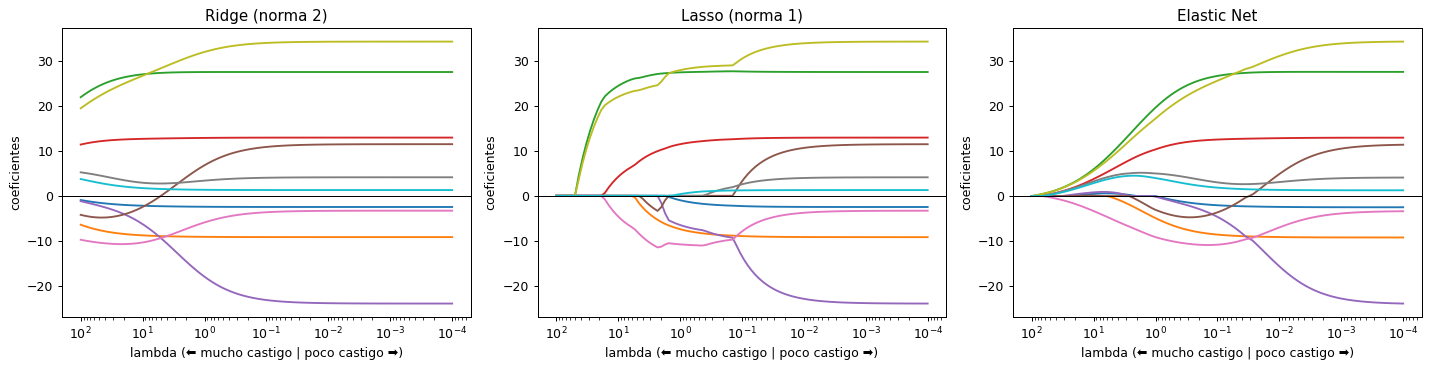

En Lasso las líneas TOCAN el cero y se quedan ahí: eso es selección de
variables. En Ridge se acercan a cero pero nunca lo tocan.


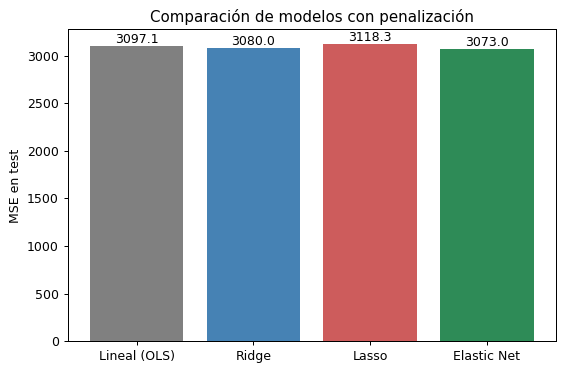

Mejor modelo: Elastic Net


In [11]:
# ═══ A9. Ridge, Lasso y Elastic Net ═══
# ⚠️ SIEMPRE con Xs (estandarizado)

alphas = np.logspace(-4, 2, 100)     # ⬅ rejilla de lambdas a probar

# ── 1. RIDGE ────────────────────────────────────────────────────────────
ridge = RidgeCV(alphas=alphas, cv=10).fit(Xs_train, y_train)
mse_ridge = mean_squared_error(y_test, ridge.predict(Xs_test))
print(f"RIDGE   lambda óptimo = {ridge.alpha_:.5f}   MSE test = {mse_ridge:.3f}")
print(f"        coeficientes en cero: {np.sum(ridge.coef_ == 0)} de {len(ridge.coef_)}  <- Ridge NUNCA da ceros")

# ── 2. LASSO ────────────────────────────────────────────────────────────
lasso = LassoCV(alphas=alphas, cv=10, max_iter=10000, random_state=0).fit(Xs_train, y_train)
mse_lasso = mean_squared_error(y_test, lasso.predict(Xs_test))
n_cero = np.sum(lasso.coef_ == 0)
print(f"\nLASSO   lambda óptimo = {lasso.alpha_:.5f}   MSE test = {mse_lasso:.3f}")
print(f"        coeficientes en cero: {n_cero} de {len(lasso.coef_)}  <- SELECCIONA variables")
print(f"        variables que sobreviven: {[nombres_X[i] for i in np.where(lasso.coef_ != 0)[0]]}")

# ── 3. ELASTIC NET ──────────────────────────────────────────────────────
elastic = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[.1, .3, .5, .7, .9, .95, 1],   # ⬅ calibra también la mezcla
    cv=10, max_iter=10000, random_state=0,
).fit(Xs_train, y_train)
mse_elastic = mean_squared_error(y_test, elastic.predict(Xs_test))
print(f"\nELASTIC lambda = {elastic.alpha_:.5f}  l1_ratio = {elastic.l1_ratio_}  MSE test = {mse_elastic:.3f}")

# ── GRÁFICA CLAVE: caminos de los coeficientes ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, Modelo, nombre, kw in [
        (axes[0], Ridge,      "Ridge (norma 2)",     {}),
        (axes[1], Lasso,      "Lasso (norma 1)",     {"max_iter": 10000}),
        (axes[2], ElasticNet, "Elastic Net",         {"max_iter": 10000, "l1_ratio": 0.5})]:
    coefs = [Modelo(alpha=a, **kw).fit(Xs_train, y_train).coef_ for a in alphas]
    ax.plot(alphas, coefs)
    ax.set_xscale("log"); ax.invert_xaxis()     # lambda grande a la izquierda
    ax.axhline(0, color="k", lw=.8)
    ax.set_xlabel("lambda (⬅ mucho castigo | poco castigo ➡)")
    ax.set_ylabel("coeficientes"); ax.set_title(nombre)
plt.tight_layout(); plt.show()
print("En Lasso las líneas TOCAN el cero y se quedan ahí: eso es selección de")
print("variables. En Ridge se acercan a cero pero nunca lo tocan.")

# ── Comparación final ───────────────────────────────────────────────────
mse_ols = mean_squared_error(y_test, LinearRegression().fit(Xs_train, y_train).predict(Xs_test))
nombres_m = ["Lineal (OLS)", "Ridge", "Lasso", "Elastic Net"]
valores_m = [mse_ols, mse_ridge, mse_lasso, mse_elastic]

plt.bar(nombres_m, valores_m, color=["gray","steelblue","indianred","seagreen"])
plt.ylabel("MSE en test"); plt.title("Comparación de modelos con penalización")
for i, v in enumerate(valores_m): plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.show()
print(f"Mejor modelo: {nombres_m[int(np.argmin(valores_m))]}")

<a id="a10"></a>
---
# A10. Comparación final de modelos

Este bloque corre todos los modelos supervisados vistos en el curso sobre tus datos y los ordena por MSE de test. Es el cierre típico de un punto del parcial.

**Cómo se reporta:** siempre el error en **test** (nunca en train), y menciona qué parámetro se calibró en cada modelo y cómo.

          modelo    MSE test      RMSE
     Elastic Net 3072.953978 55.434231
           Ridge 3080.008089 55.497821
    Lineal (OLS) 3097.119163 55.651767
           Lasso 3118.305197 55.841787
Forward (6 vars) 3126.015857 55.910785
      KNN (k=12) 3298.299342 57.430822

🏆 Mejor modelo: Elastic Net  (MSE = 3072.954)


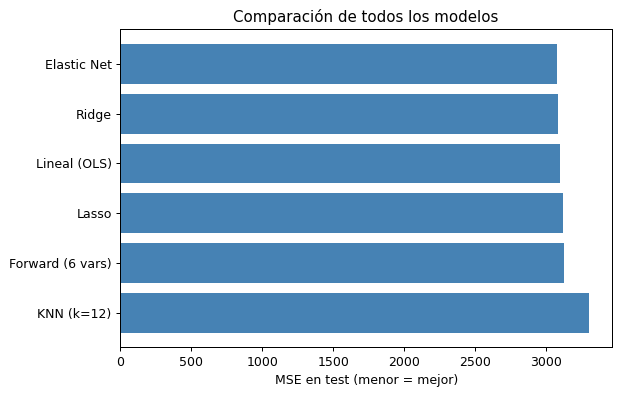

In [12]:
# ═══ A10. Comparar todos los modelos de un golpe ═══

resultados = {}

# Lineal
resultados["Lineal (OLS)"] = mean_squared_error(y_test,
    LinearRegression().fit(X_train, y_train).predict(X_test))

# KNN calibrado por CV
k_best = GridSearchCV(KNeighborsRegressor(), {"n_neighbors": range(1, 41)},
                      cv=10, scoring="neg_mean_squared_error").fit(Xs_train, y_train)
resultados[f"KNN (k={k_best.best_params_['n_neighbors']})"] = mean_squared_error(
    y_test, k_best.predict(Xs_test))

# Penalizados
resultados["Ridge"]       = mse_ridge
resultados["Lasso"]       = mse_lasso
resultados["Elastic Net"] = mse_elastic

# Forward
resultados[f"Forward ({k_opt} vars)"] = mse_fwd

# ── Tabla ordenada ──────────────────────────────────────────────────────
tabla = pd.DataFrame({"modelo": list(resultados.keys()),
                      "MSE test": list(resultados.values())})
tabla["RMSE"] = np.sqrt(tabla["MSE test"])
tabla = tabla.sort_values("MSE test").reset_index(drop=True)
print(tabla.to_string(index=False))
print(f"\n🏆 Mejor modelo: {tabla.iloc[0]['modelo']}  (MSE = {tabla.iloc[0]['MSE test']:.3f})")

plt.barh(tabla["modelo"][::-1], tabla["MSE test"][::-1], color="steelblue")
plt.xlabel("MSE en test (menor = mejor)"); plt.title("Comparación de todos los modelos")
plt.tight_layout(); plt.show()

---
# PARTE B — APRENDIZAJE NO SUPERVISADO

> Aquí **no se usa `y`**. Todos los métodos trabajan solo con `Xs` (estandarizado).
> Si tu problema es no supervisado, pon `TARGET = None` en el bloque de carga.

<a id="b1"></a>
---
# B1. K-Means

## Qué hace, en simple
Parte los datos en **K grupos**. Cada grupo tiene un **centro** (el promedio de sus puntos), y cada punto se asigna **al centro más cercano**. Repite: recalcula centros → reasigna puntos, hasta que nada cambia.

## Fórmula
$$\min \sum_{k}\sum_{x\in C_k}\|x-\bar x_k\|^2 \quad (\text{WSS})$$

**Identidad ANOVA:** $SST = BSS + WSS$, con $SST$ fijo ⇒ **minimizar WSS = maximizar BSS**. Coherencia interna y separación son el mismo objetivo.

## Parámetros
| Parámetro | Qué poner |
|---|---|
| `n_clusters` (K) | El número de grupos. **Calibrar con el codo o Silhouette (B5)** |
| `n_init` | **10 o más.** Repite con distintos arranques y se queda con el mejor. Defensa contra óptimos locales |
| `init` | `'k-means++'` (por defecto, mejor que aleatorio) |
| `random_state` | Fijo, para reproducir |

## Ventajas / desventajas
✅ Rapidísimo, escala a millones · centroides interpretables · asigna puntos nuevos sin reentrenar
❌ **Hay que fijar K** · sensible a inicialización, escala y outliers · **solo clusters redondos y de tamaño parecido** · **siempre devuelve K grupos aunque no haya estructura**

WSS (inercia) : 2879.20
tamaño grupos : [161 124 157]
SST = 4420.0 = BSS (1540.8) + WSS (2879.2)
varianza explicada (BSS/SST): 0.349

Centroides (en unidades estandarizadas):
    age   sex   bmi    bp    s1    s2    s3    s4    s5    s6
0 -0.57 -0.57 -0.69 -0.69 -0.50 -0.57  0.74 -0.82 -0.79 -0.67
1  0.38  0.26  0.54  0.45  1.08  1.04 -0.52  1.07  0.91  0.68
2  0.28  0.38  0.28  0.35 -0.35 -0.24 -0.35 -0.00  0.09  0.15


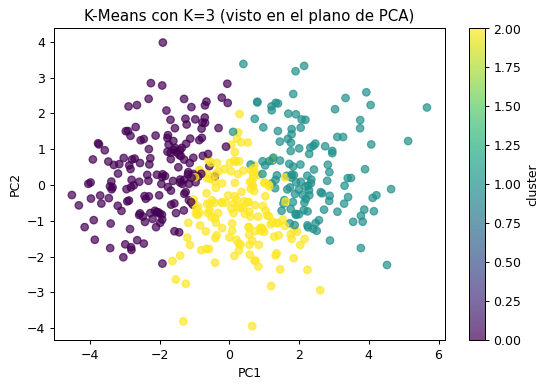

In [13]:
# ═══ B1. K-Means ═══  (usa Xs: estandarizado)
K = 3                                   # ⬅ cambia el número de grupos

km = KMeans(n_clusters=K, n_init=10, init="k-means++", random_state=0).fit(Xs)

print(f"WSS (inercia) : {km.inertia_:.2f}")
print(f"tamaño grupos : {np.bincount(km.labels_)}")

# Identidad ANOVA
SST = np.sum((Xs - Xs.mean(0))**2)
print(f"SST = {SST:.1f} = BSS ({SST-km.inertia_:.1f}) + WSS ({km.inertia_:.1f})")
print(f"varianza explicada (BSS/SST): {(SST-km.inertia_)/SST:.3f}")

# Centroides en unidades originales (más fáciles de interpretar)
centros = pd.DataFrame(km.cluster_centers_, columns=nombres_X)
print("\nCentroides (en unidades estandarizadas):")
print(centros.round(2).to_string())

# ── Gráfica: siempre en el plano de las 2 primeras componentes ──────────
Z2 = PCA(n_components=2).fit_transform(Xs)
plt.scatter(Z2[:,0], Z2[:,1], c=km.labels_, cmap="viridis", alpha=.7)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"K-Means con K={K} (visto en el plano de PCA)")
plt.colorbar(label="cluster"); plt.show()

<a id="b2"></a>
---
# B2. K-Medoides (PAM) y distancia de Gower

## Qué hace, en simple
Igual que K-Means, pero el centro de cada grupo es **una observación real** (el *medoide*), no un promedio inventado.

$$\text{medoide}_k = \arg\min_{x_j\in C_k}\sum_{x_i\in C_k} d(x_i,x_j)$$

## Por qué importa el cambio
1. **Robusto a outliers**: un punto extremo puede arrastrar un promedio, pero no puede "sacar" al medoide de los datos.
2. **Solo necesita una matriz de distancias** → sirve con **variables categóricas o mixtas** usando **Gower**.

## Distancia de Gower, en simple
Compara dos observaciones variable por variable: si es numérica, la diferencia escalada por el rango; si es categórica, 0 si son iguales y 1 si son distintas. Luego **promedia**. Da un número entre 0 y 1.

## Parámetros
| Parámetro | Qué poner |
|---|---|
| `D` (matriz de distancias) | **La decisión más importante.** Euclidiana (numéricas) o Gower (mixtas) |
| `medoids` (K) | Número de grupos |

❌ **Costoso**: la matriz es $n\times n$. Con $n>10{,}000$ ya pesa. Alternativa: `CLARA`.

pérdida total : 1149.793


medoides      : filas [302 195 156] del dataset
tamaño grupos : [ 95 145 202]

Los medoides son observaciones REALES:
      age   sex   bmi    bp    s1    s2    s3    s4    s5    s6
302  0.01 -0.04  0.03  0.03  0.03  0.03 -0.00  0.01  0.03  0.03
195  0.03  0.05  0.03  0.01  0.03  0.05 -0.04  0.03  0.01  0.02
156 -0.02 -0.04 -0.01  0.00 -0.04 -0.04  0.01 -0.04 -0.02 -0.03


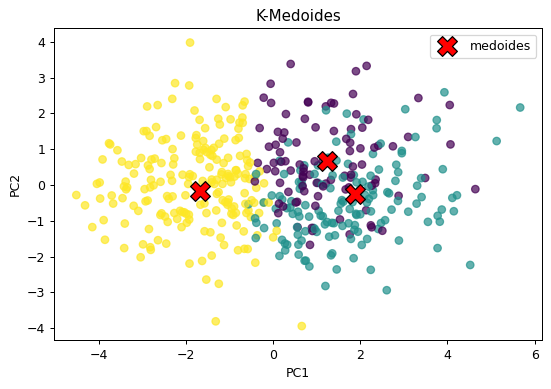

In [14]:
# ═══ B2. K-Medoides ═══
import kmedoids
from scipy.spatial.distance import squareform, pdist

K = 3

# Opción A: distancia euclidiana (variables numéricas)
D = squareform(pdist(Xs, metric="euclidean"))

# Opción B: distancia de Gower (variables mixtas / categóricas)
#   import gower
#   D = gower.gower_matrix(X_df.astype(object)).astype(np.float64)

res = kmedoids.fasterpam(D, medoids=K)
print(f"pérdida total : {res.loss:.3f}")
print(f"medoides      : filas {res.medoids} del dataset")
print(f"tamaño grupos : {np.bincount(res.labels)}")
print("\nLos medoides son observaciones REALES:")
print(X_df.iloc[res.medoids].round(2).to_string())

plt.scatter(Z2[:,0], Z2[:,1], c=res.labels, cmap="viridis", alpha=.7)
plt.scatter(Z2[res.medoids,0], Z2[res.medoids,1], c="red", marker="X",
            s=250, edgecolors="black", label="medoides")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("K-Medoides"); plt.legend(); plt.show()

<a id="b3"></a>
---
# B3. Clustering jerárquico

## Qué hace, en simple
Empieza con cada punto solo. En cada paso **une los dos grupos más cercanos**. Sigue hasta que queda uno. El resultado es un **árbol (dendrograma)** que muestra todo el proceso.

Para obtener grupos concretos, **cortas el árbol** a una altura. Cortar más arriba = menos grupos.

## El linkage: lo que de verdad decide el resultado
| Linkage | Distancia entre grupos | Comportamiento |
|---|---|---|
| `single` | la **mínima** entre puntos | formas alargadas; sufre *chaining* (une grupos por una cadena de puntos) |
| `complete` | la **máxima** | grupos compactos; sensible a outliers |
| `average` | el **promedio** | término medio, buen default |
| `ward` | menor aumento de WSS | grupos balanceados, lo más parecido a K-Means |

> **El resultado depende más del linkage que del algoritmo.** En R usa `ward.D2`, no `ward.D`.

## Parámetros
`method` (el linkage) · `metric` (`euclidean` obligatoria con ward) · `t` + `criterion='maxclust'` para pedir K grupos

✅ No hay que fijar K de antemano · determinista · el dendrograma da información de parentesco
❌ **Fusiones irreversibles** (greedy) · $O(n^2)$–$O(n^3)$ · muy sensible al linkage · siempre dibuja un árbol, haya estructura o no

single    -> tamaños [440   1   1]
complete  -> tamaños [ 73  97 272]
average   -> tamaños [ 30   3 409]
ward      -> tamaños [157 118 167]


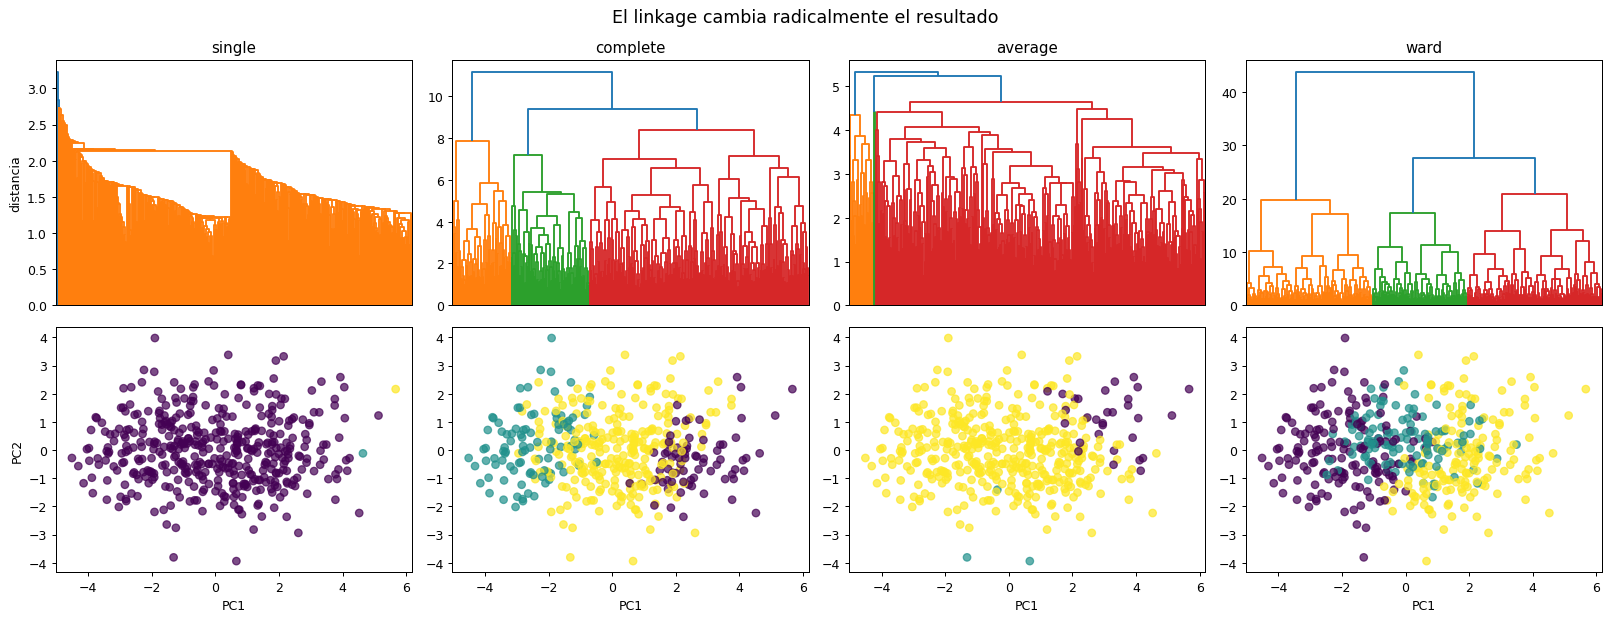

In [15]:
# ═══ B3. Clustering jerárquico ═══
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

K = 3
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for j, metodo in enumerate(["single", "complete", "average", "ward"]):
    Z = linkage(Xs, method=metodo, metric="euclidean")   # ⬅ cambia el linkage aquí
    etiquetas = fcluster(Z, t=K, criterion="maxclust")   # ⬅ 'maxclust' + t=K pide K grupos
    #  fcluster(Z, t=5.0, criterion="distance")          # alternativa: cortar a una altura

    print(f"{metodo:9s} -> tamaños {np.bincount(etiquetas)[1:]}")
    dendrogram(Z, no_labels=True, ax=axes[0,j], color_threshold=Z[-(K-1),2])
    axes[0,j].set_title(metodo); axes[0,j].set_ylabel("distancia" if j==0 else "")
    axes[1,j].scatter(Z2[:,0], Z2[:,1], c=etiquetas, cmap="viridis", alpha=.7)
    axes[1,j].set_xlabel("PC1"); axes[1,j].set_ylabel("PC2" if j==0 else "")

fig.suptitle("El linkage cambia radicalmente el resultado", fontsize=14)
plt.tight_layout(); plt.show()

<a id="b4"></a>
---
# B4. DBSCAN

## Qué hace, en simple
Busca **zonas densas**: un cluster es un montón de puntos pegados entre sí. No exige que todos los puntos del grupo estén cerca del centro, solo que haya una **cadena de vecinos densos** que los conecte. Por eso encuentra **formas raras** (espirales, anillos, medialunas).

Además, **los puntos que no caen en ninguna zona densa los marca como RUIDO** (`-1`). Es el único método de clustering del curso que dice "este punto no va en ningún lado".

## Los 3 tipos de punto
- **core**: tiene al menos `min_samples` vecinos dentro del radio `eps`
- **border**: no es core, pero está dentro del radio de un core
- **noise**: ninguna de las dos → etiqueta **`-1`**

## Cómo elegir `eps` — la curva k-dist
1. Calcula la distancia de cada punto a su k-ésimo vecino
2. Ordénalas y grafícalas
3. El **"codo"** de la curva es un buen `eps`

## Parámetros
| Parámetro | Qué poner |
|---|---|
| `eps` | **El crítico.** Radio de la vecindad. Se lee del codo de la curva k-dist |
| `min_samples` | Regla práctica: **≥ p+1**, o `2p` si hay ruido |

**Diagnóstico rápido:** casi todo es ruido → `eps` muy chico. Un solo cluster gigante → `eps` muy grande.

✅ Formas arbitrarias · no fija K · detecta outliers
❌ Calibración difícil y muy sensible · **falla si los clusters tienen densidades distintas** (usa HDBSCAN) · se degrada en dimensión alta

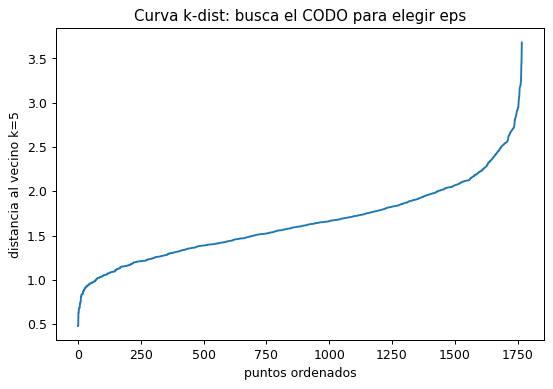

Sugerencia: eps entre 1.98 (percentil 80) y 2.47 (percentil 95)

Sensibilidad a eps:
  eps= 1.60 -> 3 clusters, 220 puntos de ruido
  eps= 1.82 -> 2 clusters, 120 puntos de ruido
  eps= 1.98 -> 2 clusters, 65 puntos de ruido
  eps= 2.20 -> 1 clusters, 29 puntos de ruido
  eps= 2.47 -> 1 clusters, 14 puntos de ruido

FINAL: eps=2.20 -> 1 clusters, 29 ruido


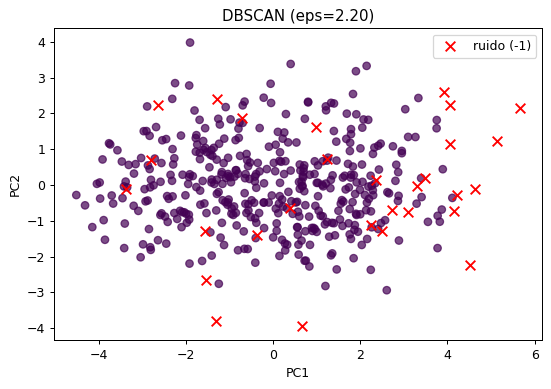

In [16]:
# ═══ B4. DBSCAN ═══
from sklearn.neighbors import NearestNeighbors

# ── Paso 1: curva k-dist para elegir eps ───────────────────────────────
k = min(5, len(Xs)-1)
d_k = np.sort(NearestNeighbors(n_neighbors=k).fit(Xs).kneighbors(Xs)[0][:,1:].reshape(-1))

plt.plot(d_k); plt.xlabel("puntos ordenados"); plt.ylabel(f"distancia al vecino k={k}")
plt.title("Curva k-dist: busca el CODO para elegir eps"); plt.show()
print(f"Sugerencia: eps entre {np.percentile(d_k,80):.2f} (percentil 80) y "
      f"{np.percentile(d_k,95):.2f} (percentil 95)")

# ── Paso 2: probar varios eps ──────────────────────────────────────────
print("\nSensibilidad a eps:")
for eps in np.round(np.percentile(d_k, [50,70,80,90,95]), 2):
    lab = DBSCAN(eps=eps, min_samples=k+1).fit_predict(Xs)
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    print(f"  eps={eps:5.2f} -> {n_cl} clusters, {int((lab==-1).sum())} puntos de ruido")

# ── Paso 3: modelo final ───────────────────────────────────────────────
EPS = float(np.percentile(d_k, 90))     # ⬅ ajusta según la curva y la tabla de arriba
db = DBSCAN(eps=EPS, min_samples=k+1).fit(Xs)

n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"\nFINAL: eps={EPS:.2f} -> {n_cl} clusters, {int((db.labels_==-1).sum())} ruido")

mask = db.labels_ == -1
plt.scatter(Z2[~mask,0], Z2[~mask,1], c=db.labels_[~mask], cmap="viridis", alpha=.7)
plt.scatter(Z2[mask,0], Z2[mask,1], c="red", marker="x", s=60, label="ruido (-1)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"DBSCAN (eps={EPS:.2f})")
plt.legend(); plt.show()

<a id="b5"></a>
---
# B5. Métricas de clustering — cómo elegir K

## El problema
En clustering no hay respuesta correcta conocida. Estas métricas ayudan a decidir K.

## Método del codo
Grafica WSS vs. K. El WSS **siempre baja** (con K=n es 0), así que no se minimiza: se busca **dónde deja de bajar rápido**.

## Silhouette — la más usada
Por cada observación:
$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}\in[-1,1]$$
- $a(i)$ = distancia promedio a los de **su** grupo (cohesión)
- $b(i)$ = distancia promedio a los del grupo **vecino más cercano** (separación)

| $s(i)$ | Significa |
|---|---|
| ≈ 1 | bien asignada |
| ≈ 0 | en la frontera |
| < 0 | **probablemente mal asignada** |

Lectura del promedio: >0.7 fuerte · 0.5–0.7 razonable · 0.25–0.5 débil · <0.25 sin estructura

## Las otras dos
- **Calinski-Harabasz** = $\frac{BSS/(K-1)}{WSS/(n-K)}$ → **maximizar**
- **Davies-Bouldin** → **minimizar**

## ⚠️ La trampa (esto lo preguntan)
**Las tres asumen clusters redondos y separados por sus centros.** Con anillos concéntricos premian a K-Means aunque esté visiblemente mal, porque los dos anillos comparten centroide. **No las uses para comparar K-Means contra DBSCAN en formas irregulares.**

Y si las tres discrepan: no las promedies. Significa que **no hay estructura clara** y K se decide por criterio del problema.

  K |       WSS | Silhouette | Calinski-H |  Davies-B
----------------------------------------------------
  2 |    3176.7 |      0.237 |      172.2 |     1.545
  3 |    2879.2 |      0.153 |      117.5 |     1.997
  4 |    2642.4 |      0.141 |       98.2 |     1.925
  5 |    2455.6 |      0.142 |       87.4 |     1.870
  6 |    2303.4 |      0.144 |       80.1 |     1.804
  7 |    2202.6 |      0.140 |       73.0 |     1.734
  8 |    2099.3 |      0.138 |       68.5 |     1.747
  9 |    2007.3 |      0.140 |       65.1 |     1.699
 10 |    1941.0 |      0.141 |       61.3 |     1.707

Mejor K según Silhouette       : 2
Mejor K según Calinski-Harabasz: 2
Mejor K según Davies-Bouldin   : 2


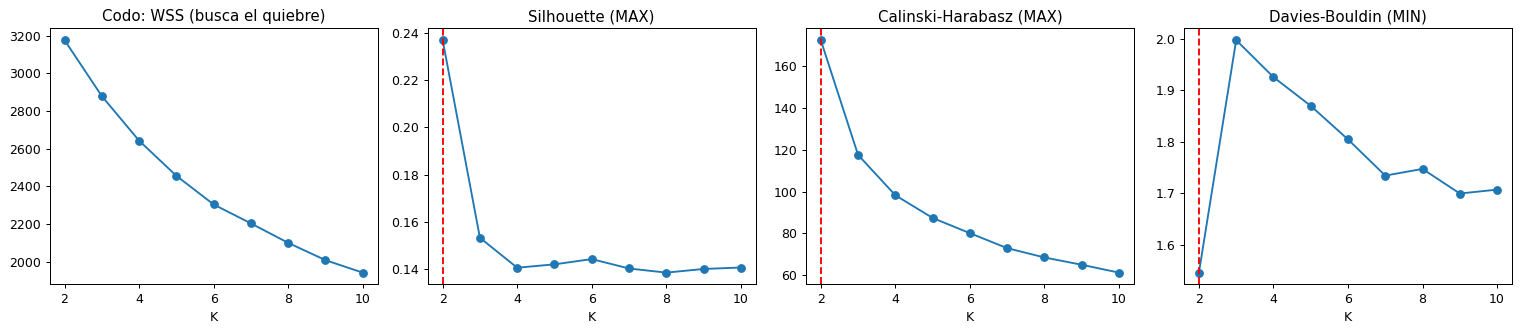

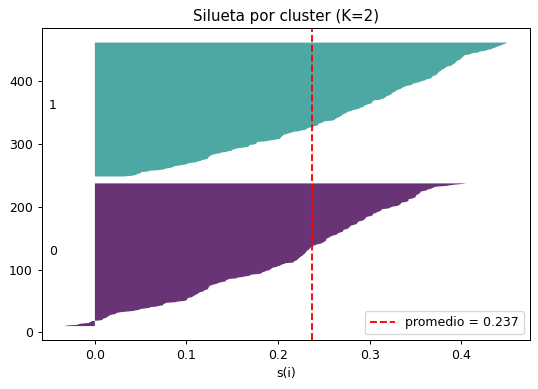

Observaciones con s(i)<0 (mal asignadas): 9


In [17]:
# ═══ B5. Elegir K ═══
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)

Ks = range(2, 11)
wss, sil, ch, db_i = [], [], [], []

for k in Ks:
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    wss.append(KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs).inertia_)
    sil.append(silhouette_score(Xs, lab))            # MAXIMIZAR
    ch.append(calinski_harabasz_score(Xs, lab))      # MAXIMIZAR
    db_i.append(davies_bouldin_score(Xs, lab))       # MINIMIZAR

print(f"{'K':>3} | {'WSS':>9} | {'Silhouette':>10} | {'Calinski-H':>10} | {'Davies-B':>9}")
print("-"*52)
for i,k in enumerate(Ks):
    print(f"{k:3d} | {wss[i]:9.1f} | {sil[i]:10.3f} | {ch[i]:10.1f} | {db_i[i]:9.3f}")

k_sil = list(Ks)[int(np.argmax(sil))]
print(f"\nMejor K según Silhouette       : {k_sil}")
print(f"Mejor K según Calinski-Harabasz: {list(Ks)[int(np.argmax(ch))]}")
print(f"Mejor K según Davies-Bouldin   : {list(Ks)[int(np.argmin(db_i))]}")

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, v, t, best in [(ax[0], wss, "Codo: WSS (busca el quiebre)", None),
                      (ax[1], sil, "Silhouette (MAX)", np.argmax(sil)),
                      (ax[2], ch,  "Calinski-Harabasz (MAX)", np.argmax(ch)),
                      (ax[3], db_i,"Davies-Bouldin (MIN)", np.argmin(db_i))]:
    a.plot(list(Ks), v, "o-"); a.set_xlabel("K")
    if best is not None: a.axvline(list(Ks)[best], color="red", ls="--")
    a.set_title(t)
plt.tight_layout(); plt.show()

# ── Gráfico de silueta por cluster (más informativo que el promedio) ───
import matplotlib.cm as cm
lab = KMeans(n_clusters=k_sil, n_init=10, random_state=0).fit_predict(Xs)
si = silhouette_samples(Xs, lab)
y_low = 10
fig, a = plt.subplots(figsize=(7,4.5))
for kk in range(k_sil):
    v = np.sort(si[lab==kk]); y_up = y_low+len(v)
    a.fill_betweenx(np.arange(y_low,y_up), 0, v, facecolor=cm.viridis(kk/k_sil), alpha=.8)
    a.text(-0.05, y_low+.5*len(v), str(kk)); y_low = y_up+10
a.axvline(si.mean(), color="red", ls="--", label=f"promedio = {si.mean():.3f}")
a.set_xlabel("s(i)"); a.set_title(f"Silueta por cluster (K={k_sil})"); a.legend()
plt.show()
print(f"Observaciones con s(i)<0 (mal asignadas): {int((si<0).sum())}")

<a id="b6"></a>
---
# B6. Outliers: Z-Score y Mahalanobis

## Z-Score (una variable a la vez)
$$Z(x_i)=\frac{x_i-\bar x}{sd}$$
Regla: $|Z|>3$ es atípico (≈0.27% bajo normalidad).

### ⚠️ El enmascaramiento
Los outliers **inflan la media y la sd**, y así **se esconden a sí mismos**. Con varios outliers juntos, sus propios Z caen bajo 3 y no se detectan. Además el Z tiene un **techo**: $|Z|\le\frac{n-1}{\sqrt n}$.

**Solución: Z modificado**, con mediana y MAD (aguanta hasta 50% de contaminación):
$$Z_{mod}=\frac{0.6745(x_i-\text{mediana})}{MAD}$$

## Mahalanobis (todas las variables juntas)
$$d_M(x)^2=(x-\bar x)^\top S^{-1}(x-\bar x)\sim\chi^2_p$$

Corrige por **escala y correlación**. Sus fronteras son **elipses**, no círculos.
**Umbral formal:** percentil 97.5 de $\chi^2_p$ (con $p$ = número de **variables**).

> **Clave:** mirar variable por variable **NO** es lo mismo que Mahalanobis. Un punto puede ser normal en cada variable y atípico en conjunto por **romper la correlación**.

## Caso Hadlum (lo preguntan)
Un embarazo de 349 días es improbable pero posible. **Un outlier estadístico no es automáticamente un error o un fraude**: es una observación improbable *bajo el modelo asumido*. Con n grande, siempre habrá puntos en las colas.

## Versión robusta
`MinCovDet` (MCD) estima la covarianza con la mayoría "limpia" de los datos → no se deja engañar por el grupo contaminante.

Outliers por variable (|Z| > 3):
  age                    Z clásico:   0   Z modificado:   0
  sex                    Z clásico:   0   Z modificado: 207
  bmi                    Z clásico:   2   Z modificado:   3
  bp                     Z clásico:   0   Z modificado:   0
  s1                     Z clásico:   2   Z modificado:   2
  s2                     Z clásico:   2   Z modificado:   4
  s3                     Z clásico:   5   Z modificado:   7
  s4                     Z clásico:   4   Z modificado:   1
  s5                     Z clásico:   0   Z modificado:   0
  s6                     Z clásico:   0   Z modificado:   6
El Z modificado detecta MÁS porque no se deja enmascarar.

umbral chi2(0.975, df=10) = 20.48
atípicos, Mahalanobis clásica : 26
atípicos, Mahalanobis robusta : 134  <- detecta más


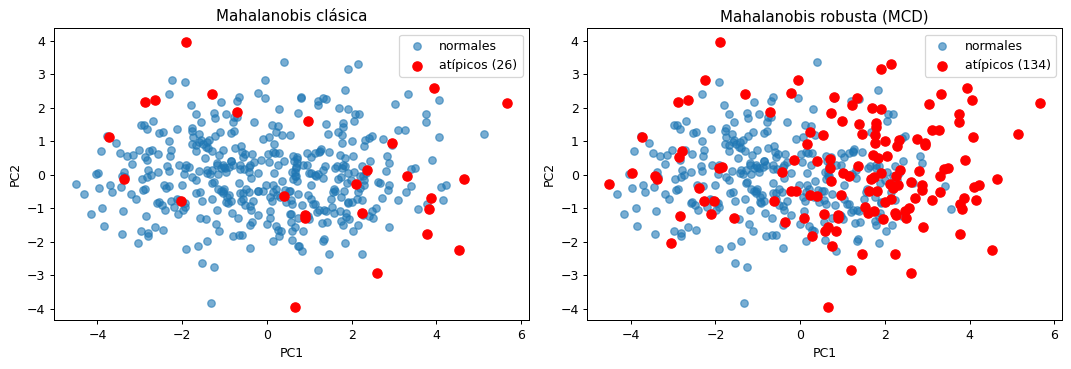


Filas más atípicas (índices): [169  23 353 322 394 323 371 254]


In [18]:
# ═══ B6. Outliers estadísticos ═══
from scipy.stats import chi2
from sklearn.covariance import MinCovDet

# ── Z-Score clásico y modificado, por variable ─────────────────────────
z = np.abs((X - X.mean(0)) / X.std(0))
mad = np.median(np.abs(X - np.median(X,0)), axis=0)
z_mod = np.abs(0.6745 * (X - np.median(X,0)) / np.where(mad==0, 1e-9, mad))

print("Outliers por variable (|Z| > 3):")
for j, nom in enumerate(nombres_X):
    print(f"  {nom:22s} Z clásico: {int((z[:,j]>3).sum()):3d}   Z modificado: {int((z_mod[:,j]>3).sum()):3d}")
print("El Z modificado detecta MÁS porque no se deja enmascarar.")

# ── Mahalanobis clásica y robusta ──────────────────────────────────────
p_var = X.shape[1]
umbral = chi2.ppf(0.975, df=p_var)          # ⬅ df = nº de VARIABLES

dif = X - X.mean(0)
d2 = np.einsum("ij,jk,ik->i", dif, np.linalg.inv(np.cov(X, rowvar=False)), dif)
d2_rob = MinCovDet(random_state=0).fit(X).mahalanobis(X)   # versión robusta (MCD)

print(f"\numbral chi2(0.975, df={p_var}) = {umbral:.2f}")
print(f"atípicos, Mahalanobis clásica : {int((d2>umbral).sum())}")
print(f"atípicos, Mahalanobis robusta : {int((d2_rob>umbral).sum())}  <- detecta más")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, d, t in [(ax[0], d2, "Mahalanobis clásica"), (ax[1], d2_rob, "Mahalanobis robusta (MCD)")]:
    m = d > umbral
    a.scatter(Z2[~m,0], Z2[~m,1], alpha=.6, label="normales")
    a.scatter(Z2[m,0], Z2[m,1], c="red", s=55, label=f"atípicos ({int(m.sum())})")
    a.set_xlabel("PC1"); a.set_ylabel("PC2"); a.set_title(t); a.legend()
plt.tight_layout(); plt.show()

print(f"\nFilas más atípicas (índices): {np.argsort(d2_rob)[::-1][:8]}")

<a id="b7"></a>
---
# B7. Outliers: LOF e Isolation Forest

Estos dos atacan el problema desde ángulos **opuestos**.

## LOF (Local Outlier Factor)
Compara la **densidad de un punto con la de sus vecinos**. Si vive en una zona mucho más vacía que sus vecinos, es outlier.

| Valor | Significa |
|---|---|
| $LOF\approx 1$ | densidad normal |
| $LOF\gg 1$ | **outlier** |
| $LOF<1$ | dentro de un cluster denso |

Detecta **outliers LOCALES**: puntos normales globalmente pero raros en su vecindario.

> ⚠️ En sklearn, `negative_outlier_factor_` es **−LOF**: más negativo = más atípico. En R (`dbscan::lof`) es al revés.

## Isolation Forest
Idea distinta: **los puntos raros son fáciles de aislar**. Hace cortes aleatorios; un outlier queda solo tras pocos cortes, un punto en el montón necesita muchos. El puntaje es la longitud del camino.

Detecta **outliers GLOBALES**. Es $O(n\log n)$ → escala muy bien.

## Cuál usar
| Situación | Método |
|---|---|
| n grande, muchas variables | **Isolation Forest** |
| Clusters de densidades muy distintas | **LOF** |
| Pocas variables, datos ~normales | **Mahalanobis** (B6) |

**En la práctica: corre varios y mira dónde coinciden.**

## Parámetros
| Parámetro | Qué poner |
|---|---|
| `n_neighbors` (LOF) | **El crítico.** 10–35. Pequeño = ruidoso; grande = se vuelve global |
| `n_estimators` (iForest) | 100 basta |
| `max_samples` | 256 funciona tan bien como usar todo |
| `contamination` | Proporción esperada de outliers. `'auto'`, o fija un valor si lo sabes |

outliers según LOF            : 0
outliers según Isolation Forest: 65

coinciden en                  : 0
solo LOF (LOCALES)            : 0
solo iForest (GLOBALES)       : 65


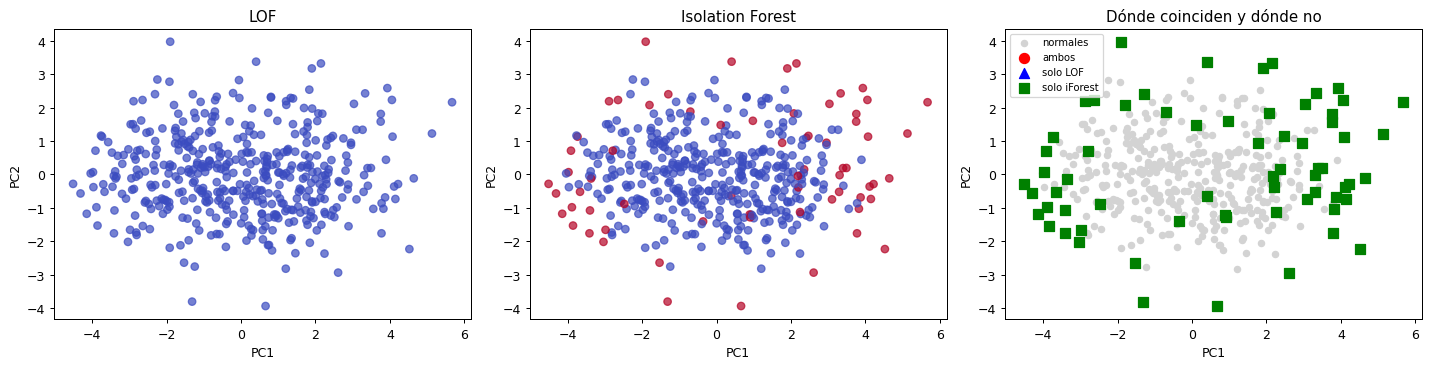


Filas más anómalas según iForest: [123 336 321 405 141 161 322 230]


In [19]:
# ═══ B7. LOF e Isolation Forest ═══

# ── LOF ────────────────────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination="auto")  # ⬅ n_neighbors: el crítico
y_lof = lof.fit_predict(Xs)                      # -1 = outlier, 1 = normal
score_lof = lof.negative_outlier_factor_         # ⬅ es -LOF: más negativo = más atípico

# ── Isolation Forest ───────────────────────────────────────────────────
iso = IsolationForest(n_estimators=100, max_samples=256,
                      contamination="auto", random_state=0).fit(Xs)
y_if = iso.predict(Xs)                           # -1 = outlier
score_if = iso.decision_function(Xs)             # ⬅ más BAJO = más anómalo

es_lof, es_if = y_lof==-1, y_if==-1
print(f"outliers según LOF            : {int(es_lof.sum())}")
print(f"outliers según Isolation Forest: {int(es_if.sum())}")
print(f"\ncoinciden en                  : {int((es_lof & es_if).sum())}")
print(f"solo LOF (LOCALES)            : {int((es_lof & ~es_if).sum())}")
print(f"solo iForest (GLOBALES)       : {int((~es_lof & es_if).sum())}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].scatter(Z2[:,0], Z2[:,1], c=es_lof, cmap="coolwarm", alpha=.7); ax[0].set_title("LOF")
ax[1].scatter(Z2[:,0], Z2[:,1], c=es_if, cmap="coolwarm", alpha=.7); ax[1].set_title("Isolation Forest")
ax[2].scatter(Z2[~es_lof & ~es_if,0], Z2[~es_lof & ~es_if,1], c="lightgray", s=25, label="normales")
ax[2].scatter(Z2[es_lof & es_if,0],   Z2[es_lof & es_if,1],   c="red", s=65, label="ambos")
ax[2].scatter(Z2[es_lof & ~es_if,0],  Z2[es_lof & ~es_if,1],  c="blue", marker="^", s=65, label="solo LOF")
ax[2].scatter(Z2[~es_lof & es_if,0],  Z2[~es_lof & es_if,1],  c="green", marker="s", s=65, label="solo iForest")
ax[2].legend(fontsize=8); ax[2].set_title("Dónde coinciden y dónde no")
for a in ax: a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.show()

print(f"\nFilas más anómalas según iForest: {np.argsort(score_if)[:8]}")

<a id="b8"></a>
---
# B8. PCA (Análisis de Componentes Principales)

## Qué hace, en simple
Tienes muchas variables correlacionadas entre sí (redundantes). PCA las **resume en unas pocas variables nuevas** (los componentes), que son **combinaciones lineales** de las originales y no están correlacionadas entre sí. El primer componente es **la dirección donde los datos más se dispersan**.

## Fórmula
$$\max_{\|w\|=1}\operatorname{Var}(Xw)=w^\top S w \quad\Rightarrow\quad S=W\Lambda W^\top$$
- $w_j$ = autovector $j$ = componente $j$ (los **loadings**)
- $\lambda_j$ = autovalor = varianza en esa dirección
- **Scores** (coordenadas nuevas): $Z=(X-\bar X)W$
- Varianza explicada: $\lambda_j/\sum\lambda_i$

## Los coeficientes de cada componente
Están en **`pca.components_`**: una **fila por componente**, una **columna por variable**. Norma 1 cada fila.
> **El signo es arbitrario**: $-w$ también es autovector. R y Python pueden dar signos opuestos; no es un error.

## Cómo elegir cuántos componentes
- **Scree plot (codo)**: grafica $\lambda_j$ y busca dónde se aplana
- **Varianza acumulada**: quedarte con ~90%
- **Kaiser**: sobre datos estandarizados, los de $\lambda_j>1$

## Parámetros
| Parámetro | Qué poner |
|---|---|
| `n_components` | Un entero, o un **float en (0,1)** para pedir esa fracción de varianza (ej. `0.95`) |
| **Estandarizar antes** | **Crítico.** sklearn centra pero NO estandariza. Usar `Xs` = trabajar con la matriz de correlación |

✅ Óptimo entre proyecciones lineales · solución cerrada · elimina multicolinealidad · proyecta datos nuevos
❌ **Solo estructura lineal** · **componentes difíciles de interpretar** (mezclan todas las variables) · sensible a escala y outliers · **maximizar varianza ≠ maximizar información útil**

Varianza explicada por componente:
  PC1: lambda= 4.0333  (40.24%)  acumulada=40.24%
  PC2: lambda= 1.4957  (14.92%)  acumulada=55.17%
  PC3: lambda= 1.2087  (12.06%)  acumulada=67.22%
  PC4: lambda= 0.9576  ( 9.55%)  acumulada=76.78%
  PC5: lambda= 0.6637  ( 6.62%)  acumulada=83.40%
  PC6: lambda= 0.6041  ( 6.03%)  acumulada=89.43%
  PC7: lambda= 0.5378  ( 5.37%)  acumulada=94.79%
  PC8: lambda= 0.4347  ( 4.34%)  acumulada=99.13%
  PC9: lambda= 0.0785  ( 0.78%)  acumulada=99.91%
  PC10: lambda= 0.0086  ( 0.09%)  acumulada=100.00%

Se necesitan 7 componentes para explicar el 90% de la varianza.
Criterio de Kaiser (lambda>1): 3 componentes

Loadings (coeficientes de cada componente):
       PC1    PC2    PC3    PC4
age  0.216  0.044  0.495  0.414
sex  0.187 -0.387 -0.107  0.680
bmi  0.303 -0.156  0.168 -0.500
bp   0.272 -0.138  0.514  0.020
s1   0.343  0.573 -0.069  0.068
s2   0.352  0.456 -0.270  0.168
s3  -0.282  0.506  0.386  0.076
s4   0.429 -0.068 -0.381 -0.008
s5   0.379 -0.026  0

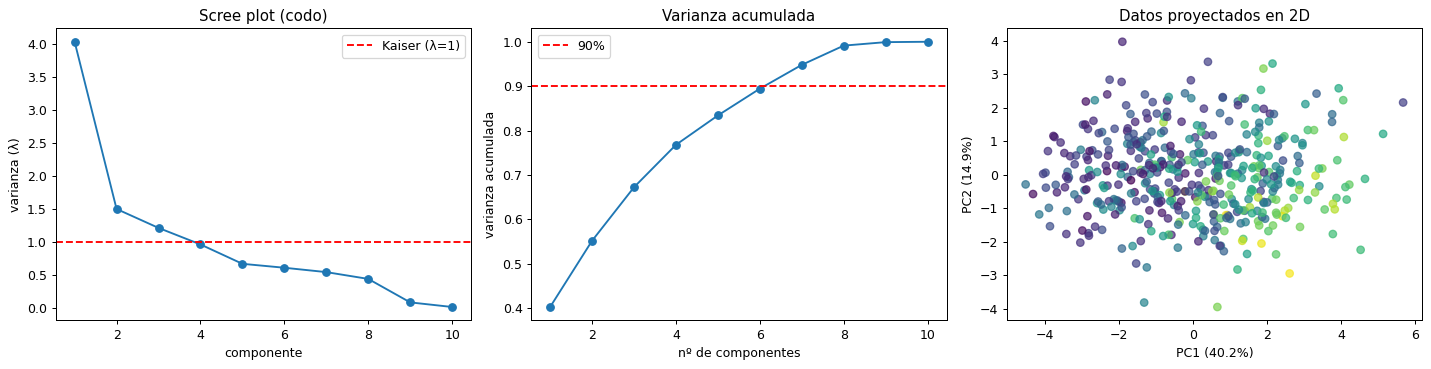

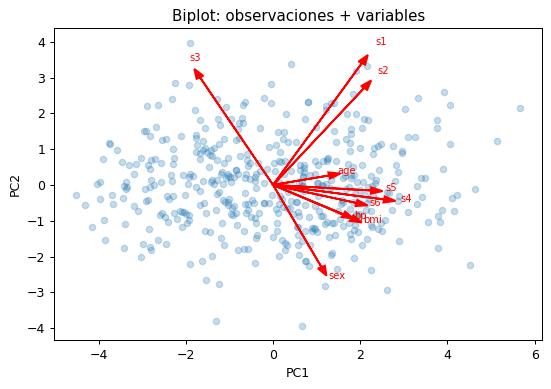

In [20]:
# ═══ B8. PCA ═══  (usa Xs)
pca = PCA(n_components=None).fit(Xs)     # ⬅ None = todos; 0.95 = los que expliquen 95%
Z = pca.transform(Xs)                    # Z = los SCORES (coordenadas nuevas)

print("Varianza explicada por componente:")
for i,(lam,r) in enumerate(zip(pca.explained_variance_, pca.explained_variance_ratio_),1):
    print(f"  PC{i}: lambda={lam:7.4f}  ({r:6.2%})  acumulada={pca.explained_variance_ratio_[:i].sum():6.2%}")

n_90 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90)) + 1
print(f"\nSe necesitan {n_90} componentes para explicar el 90% de la varianza.")
print(f"Criterio de Kaiser (lambda>1): {int((pca.explained_variance_>1).sum())} componentes")

# ── LOS COEFICIENTES (loadings) ────────────────────────────────────────
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
                        index=nombres_X)
print("\nLoadings (coeficientes de cada componente):")
print(loadings.iloc[:, :min(4, loadings.shape[1])].round(3).to_string())
print("\nLee cada COLUMNA: qué variables pesan más en ese componente.")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(range(1,len(pca.explained_variance_)+1), pca.explained_variance_, "o-")
ax[0].axhline(1, color="red", ls="--", label="Kaiser (λ=1)")
ax[0].set_xlabel("componente"); ax[0].set_ylabel("varianza (λ)")
ax[0].set_title("Scree plot (codo)"); ax[0].legend()

ax[1].plot(range(1,len(pca.explained_variance_)+1),
           np.cumsum(pca.explained_variance_ratio_), "o-")
ax[1].axhline(.90, color="red", ls="--", label="90%")
ax[1].set_xlabel("nº de componentes"); ax[1].set_ylabel("varianza acumulada")
ax[1].set_title("Varianza acumulada"); ax[1].legend()

col = y if y is not None else "steelblue"
sc = ax[2].scatter(Z[:,0], Z[:,1], c=col, cmap="viridis", alpha=.7)
ax[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax[2].set_title("Datos proyectados en 2D")
plt.tight_layout(); plt.show()

# ── Biplot: observaciones + flechas de variables ───────────────────────
esc = np.abs(Z[:,:2]).max() / np.abs(pca.components_[:2].T).max() * 0.6
plt.scatter(Z[:,0], Z[:,1], alpha=.25, s=25)
for i, var in enumerate(nombres_X):
    plt.arrow(0,0, pca.components_[0,i]*esc, pca.components_[1,i]*esc,
              color="red", head_width=esc*.03, lw=1.5)
    plt.text(pca.components_[0,i]*esc*1.15, pca.components_[1,i]*esc*1.15,
             var, color="red", fontsize=8)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Biplot: observaciones + variables")
plt.show()

<a id="b9"></a>
---
# B9. MDS (Multidimensional Scaling)

## Qué hace, en simple
Tienes **solo las distancias** entre observaciones, no sus coordenadas. MDS **reconstruye un mapa** de puntos que respete esas distancias.

El ejemplo clásico: con las distancias por carretera entre ciudades europeas, MDS **dibuja el mapa de Europa** sin haber visto nunca una latitud.

## Cómo funciona
Doble centrado para pasar de distancias a productos punto, y luego descomposición espectral:
$$B=-\tfrac12 C D^{(2)} C, \qquad C=I-\tfrac1n\mathbf{1}\mathbf{1}^\top$$

## ⚠️ Equivalencia clave (la preguntan)
> **MDS clásico con distancia euclidiana = PCA.** Es el mismo procedimiento visto desde dos lados: PCA descompone la covarianza ($p\times p$), MDS la de productos punto ($n\times n$).

## Autovalores negativos = diagnóstico
Si aparecen y son grandes, **la matriz D no es euclidiana**: ninguna configuración de puntos puede reproducir esas distancias exactamente. Pasa con Gower y con distancias por carretera.

## MDS no métrico (Kruskal)
Solo respeta el **orden** de las disimilitudes, no sus valores. Para datos ordinales (Likert, rankings). Minimiza el **STRESS**:
> <0.05 excelente · <0.10 bueno · <0.20 aceptable

## Parámetros
`n_components` (2 para visualizar) · `metric` (True=clásico, False=Kruskal) · `dissimilarity='precomputed'` si le pasas una matriz D

❌ $O(n^3)$ · **no proyecta datos nuevos** (PCA sí) · los ejes **no tienen interpretación** (se puede rotar/reflejar libremente)

autovalores (primeros 5): [1778.701  659.605  533.037  422.321  292.684]
negativos relevantes    : 0  (0 => D SÍ es euclidiana)
varianza explicada 2D   : 55.17%

MDS clásico vs PCA, diferencia máxima: 1.07e-14  <- deben ser iguales


STRESS-1 (no métrico): 0.2537  (<0.10 es bueno)


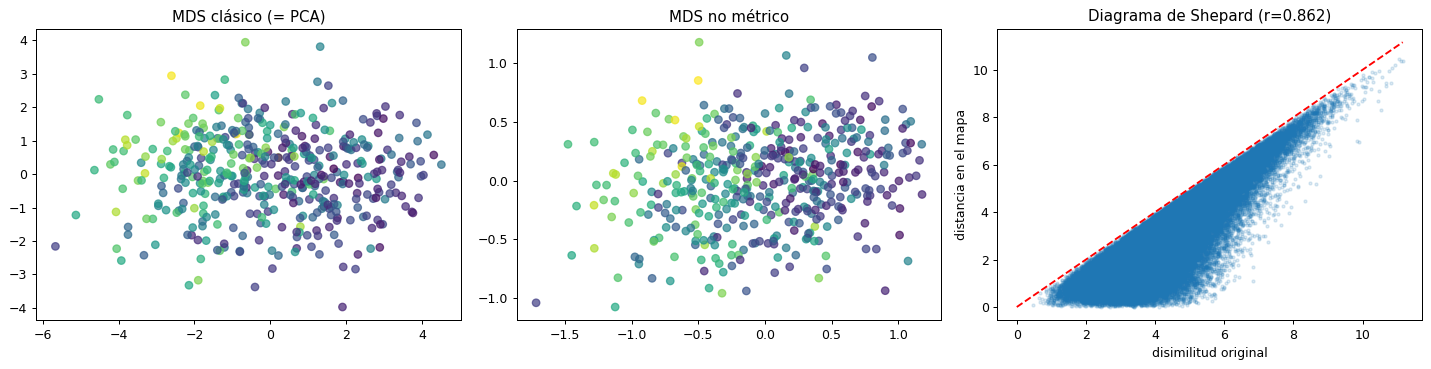

Shepard: entre más pegados a la diagonal, mejor preserva las distancias.


In [21]:
# ═══ B9. MDS ═══
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform

def cmdscale(D, k=2):
    """MDS clásico (= cmdscale de R). Devuelve (coordenadas, autovalores)."""
    n = D.shape[0]
    C = np.eye(n) - np.ones((n,n))/n          # matriz de centrado
    B = -0.5 * C @ (D**2) @ C                 # doble centrado
    val, vec = np.linalg.eigh(B)
    o = np.argsort(val)[::-1]; val, vec = val[o], vec[:,o]
    pos = val[:k] > 0
    coords = np.zeros((n,k)); coords[:,pos] = vec[:,:k][:,pos]*np.sqrt(val[:k][pos])
    return coords, val

D = squareform(pdist(Xs, metric="euclidean"))   # ⬅ cambia la métrica si quieres
pts, val = cmdscale(D, k=2)

print(f"autovalores (primeros 5): {np.round(val[:5],3)}")
print(f"negativos relevantes    : {int((val<-1e-8).sum())}  (0 => D SÍ es euclidiana)")
print(f"varianza explicada 2D   : {val[:2].sum()/val[val>0].sum():.2%}")

# Verificación: MDS clásico == PCA
print(f"\nMDS clásico vs PCA, diferencia máxima: "
      f"{np.abs(np.abs(pts)-np.abs(Z[:,:2])).max():.2e}  <- deben ser iguales")

# MDS no métrico (solo usa el ORDEN de las disimilitudes)
mds_nm = MDS(n_components=2, metric=False, dissimilarity="precomputed",
             random_state=0, n_init=4).fit_transform(D)

def stress(D_, p_):
    o, e = squareform(D_, checks=False), pdist(p_)
    s = np.sum(o*e)/np.sum(e**2)
    return np.sqrt(np.sum((o-s*e)**2)/np.sum(o**2))
print(f"STRESS-1 (no métrico): {stress(D, mds_nm):.4f}  (<0.10 es bueno)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].scatter(pts[:,0], pts[:,1], c=col, cmap="viridis", alpha=.7); ax[0].set_title("MDS clásico (= PCA)")
ax[1].scatter(mds_nm[:,0], mds_nm[:,1], c=col, cmap="viridis", alpha=.7); ax[1].set_title("MDS no métrico")
o, e = squareform(D, checks=False), pdist(pts)
ax[2].scatter(o, e, alpha=.15, s=6); lim=[0,max(o.max(),e.max())]
ax[2].plot(lim, lim, "r--"); ax[2].set_xlabel("disimilitud original")
ax[2].set_ylabel("distancia en el mapa")
ax[2].set_title(f"Diagrama de Shepard (r={np.corrcoef(o,e)[0,1]:.3f})")
plt.tight_layout(); plt.show()
print("Shepard: entre más pegados a la diagonal, mejor preserva las distancias.")

<a id="b10"></a>
---
# B10. Análisis Factorial

## Qué hace, en simple
PCA resume variables. El análisis factorial va más allá: supone que hay **causas ocultas (factores latentes)** que **producen** lo que observas.

Ejemplo clásico: nueve pruebas de habilidad mental. El modelo dice que detrás hay tres factores no observables —habilidad verbal, espacial y numérica— que causan los puntajes.

$$X = \Lambda F + \varepsilon$$
- $\Lambda$ = **cargas**: cuánto pesa cada factor sobre cada variable
- $\Psi$ = **unicidades**: la parte de cada variable que no comparte con nadie

$$\Sigma = \Lambda\Lambda^\top + \Psi$$

## La diferencia con PCA (esto lo preguntan)
| | PCA | Análisis Factorial |
|---|---|---|
| Dirección | Los componentes son **consecuencia** de las variables | Los factores son **causa** |
| Varianza | Modela **toda** | Solo la **compartida**, separa el ruido |
| Solución | Única, cerrada | Iterativa, **no única** |
| Objetivo | Comprimir | **Interpretar** |

## La rotación
La solución no es única: si $\Lambda$ sirve, $\Lambda R$ también. **Se aprovecha para hacer los factores interpretables.**
- **Varimax** (ortogonal): factores NO correlacionados. El default
- **Promax** (oblicua): permite factores correlacionados

**La rotación no cambia el ajuste, solo el sistema de ejes.**

## ⚠️ La prueba χ²
$H_0$: $m$ factores bastan.
> **p-valor ALTO = el modelo con $m$ factores SÍ es adecuado.** Es al revés de lo habitual.

**Límite de identificabilidad:** $m<\frac{2p+1-\sqrt{8p+1}}{2}$. Con $p=4$ el máximo es **1 factor** (por eso `factanal(iris,2)` da error: no es un bug).

## Verificación previa
- **Bartlett**: $H_0$ = no hay nada que factorizar. Se quiere **rechazar**
- **KMO**: >0.8 excelente · >0.6 aceptable · <0.5 inadecuado

Bartlett: p = 0.00e+00  -> hay correlaciones que factorizar
KMO     : 0.535  (>0.6 aceptable)
Máximo de factores identificables: 5  (con p=10 variables)

 m |      chi2 |  gl |   p-valor | decisión
--------------------------------------------------
 1 |   2161.06 |  35 |    0.0000 | insuficiente
 2 |    986.36 |  26 |    0.0000 | insuficiente
 3 |    173.20 |  18 |    0.0000 | insuficiente
 4 |     51.73 |  11 |    0.0000 | insuficiente
 5 |     22.32 |   5 |    0.0005 | insuficiente
⚠️  p-valor ALTO = el modelo SÍ es adecuado (al revés de lo habitual)

Cargas con rotación varimax (m=2):
     Factor1  Factor2  comunalidad  unicidad
age    0.263    0.082        0.076     0.924
sex    0.048    0.382        0.148     0.852
bmi    0.261    0.374        0.208     0.792
bp     0.248    0.186        0.096     0.904
s1     0.997   -0.029        0.995     0.005
s2     0.904    0.216        0.863     0.137
s3     0.023   -0.997        0.995     0.005
s4     0.565    0.753        0.887     0.113


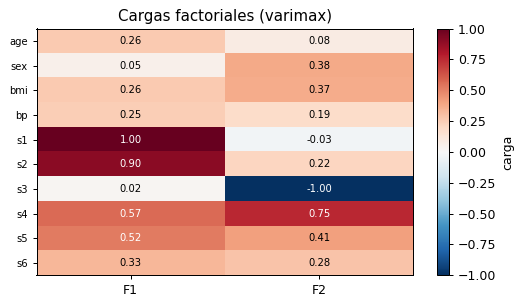

In [22]:
# ═══ B10. Análisis Factorial ═══
from scipy.optimize import minimize
from scipy.stats import chi2 as chi2_d

def factanal(R, m):
    """Análisis factorial por máxima verosimilitud (= factanal de R)."""
    p = R.shape[0]
    def crit(psi):
        psi = np.clip(psi, 1e-6, 1.0); sc = 1/np.sqrt(psi)
        ev = np.linalg.eigvalsh(sc[:,None]*R*sc[None,:])[::-1]
        e = ev[m:]; return -np.sum(np.log(e)-e) - (p-m)
    r = minimize(crit, np.diag(np.linalg.inv(R))**-1*(1-m/(2*p)),
                 method="L-BFGS-B", bounds=[(.005,1)]*p)
    psi = np.clip(r.x,.005,1); sc = 1/np.sqrt(psi)
    val, vec = np.linalg.eigh(sc[:,None]*R*sc[None,:])
    o = np.argsort(val)[::-1]; val, vec = val[o], vec[:,o]
    L = np.sqrt(psi)[:,None]*vec[:,:m]*np.sqrt(np.maximum(val[:m]-1,0))
    for j in range(m):                       # signo arbitrario: se fija por legibilidad
        if L[np.argmax(np.abs(L[:,j])),j] < 0: L[:,j] *= -1
    return L, psi, r.fun

def varimax(L, tol=1e-6, itmax=500):
    """Rotación varimax: empuja cada carga hacia 0 o ±1 para poder interpretar."""
    p_, k = L.shape; Rot = np.eye(k); d = 0.
    for _ in range(itmax):
        Lr = L@Rot
        u,s,vt = np.linalg.svd(L.T@(Lr**3 - Lr@np.diag(np.sum(Lr**2,0))/p_))
        Rot = u@vt; dn = np.sum(s)
        if d != 0 and dn/d < 1+tol: break
        d = dn
    return L@Rot

R_mat = np.corrcoef(X, rowvar=False)
n_obs, p_var = X.shape

# ── Verificación previa ────────────────────────────────────────────────
stat_b = -(n_obs-1-(2*p_var+5)/6)*np.linalg.slogdet(R_mat)[1]
p_b = 1-chi2_d.cdf(stat_b, p_var*(p_var-1)/2)
Ri = np.linalg.inv(R_mat); dd = np.sqrt(np.diag(Ri))
par = -Ri/np.outer(dd,dd); np.fill_diagonal(par,0)
Rc = R_mat.copy(); np.fill_diagonal(Rc,0)
kmo = np.sum(Rc**2)/(np.sum(Rc**2)+np.sum(par**2))

print(f"Bartlett: p = {p_b:.2e}  -> {'hay correlaciones que factorizar' if p_b<.05 else 'NADA que factorizar'}")
print(f"KMO     : {kmo:.3f}  (>0.6 aceptable)")

m_max = int(np.floor((2*p_var+1-np.sqrt(8*p_var+1))/2 - 1e-9))
print(f"Máximo de factores identificables: {m_max}  (con p={p_var} variables)")

# ── Prueba chi2 para elegir m ──────────────────────────────────────────
print(f"\n{'m':>2} | {'chi2':>9} | {'gl':>3} | {'p-valor':>9} | decisión")
print("-"*50)
for m in range(1, min(m_max, 5)+1):
    L,psi,f = factanal(R_mat, m)
    stat = (n_obs-1-(2*p_var+5)/6-2*m/3)*f
    gl = int(((p_var-m)**2-p_var-m)/2)
    pv = 1-chi2_d.cdf(stat, gl) if gl>0 else np.nan
    print(f"{m:2d} | {stat:9.2f} | {gl:3d} | {pv:9.4f} | {'ADECUADO' if pv>=.05 else 'insuficiente'}")
print("⚠️  p-valor ALTO = el modelo SÍ es adecuado (al revés de lo habitual)")

# ── Ajuste final con rotación varimax ──────────────────────────────────
M = min(2, m_max)                      # ⬅ elige m según la tabla de arriba
L, psi, _ = factanal(R_mat, M)
Lv = varimax(L) if M > 1 else L

tab = pd.DataFrame(Lv, index=nombres_X, columns=[f"Factor{i+1}" for i in range(M)])
tab["comunalidad"] = (Lv**2).sum(1)    # varianza COMPARTIDA
tab["unicidad"] = psi                  # varianza PROPIA (PCA no separa esto)
print(f"\nCargas con rotación varimax (m={M}):")
print(tab.round(3).to_string())
print("\ncomunalidad + unicidad = 1. Cargas |·|>0.3 son las que 'definen' el factor.")

fig, ax = plt.subplots(figsize=(6, max(3, .35*len(nombres_X))))
im = ax.imshow(Lv, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(M)); ax.set_xticklabels([f"F{i+1}" for i in range(M)])
ax.set_yticks(range(len(nombres_X))); ax.set_yticklabels(nombres_X, fontsize=8)
for i in range(len(nombres_X)):
    for j in range(M):
        ax.text(j,i,f"{Lv[i,j]:.2f}",ha="center",va="center",fontsize=8,
                color="white" if abs(Lv[i,j])>.5 else "black")
plt.colorbar(im, label="carga"); ax.set_title("Cargas factoriales (varimax)")
plt.tight_layout(); plt.show()

<a id="b11"></a>
---
# B11. Kernel PCA

## Qué hace, en simple
PCA solo encuentra estructura **recta**. Si los datos están sobre una curva o en círculos concéntricos, ninguna proyección lineal los separa.

KPCA los manda a un espacio de más dimensiones donde **sí** son separables linealmente, hace PCA ahí, y regresa. Lo notable: **nunca construye ese espacio**, usa el **truco del kernel** ($K(x,y)=\langle\phi(x),\phi(y)\rangle$).

## Kernels
| Kernel | Cuándo |
|---|---|
| `'linear'` | Reproduce PCA exactamente |
| `'poly'` | Interacciones entre variables |
| **`'rbf'`** | El más usado. $\exp(-\gamma\|x-y\|^2)$ |

## ⚠️ `gamma` lo decide TODO
- **muy grande** → cada punto solo se parece a sí mismo → **no hay estructura**
- **muy pequeño** → todos se parecen → **converge a PCA lineal**
- **Heurística de la mediana:** $\gamma\approx 1/\text{mediana}(\|x_i-x_j\|^2)$

> **Convención:** `kernlab` (R) usa `sigma`, sklearn usa `gamma` — **son lo mismo**. Pero otras librerías usan $\exp(-\|x-y\|^2/2\sigma^2)$, que NO lo es.

✅ Captura no linealidad · **sí proyecta datos nuevos** (MDS y t-SNE no)
❌ $O(n^3)$ · **componentes sin interpretación** · sin reconstrucción directa (*problema de la preimagen*) · **es fácil "encontrar" estructura ajustando gamma hasta que el gráfico se vea bien**

> **Regla:** verifica siempre contra PCA lineal primero. Si PCA ya resuelve, KPCA solo agrega opacidad.

gamma sugerido por la heurística de la mediana: 0.0582


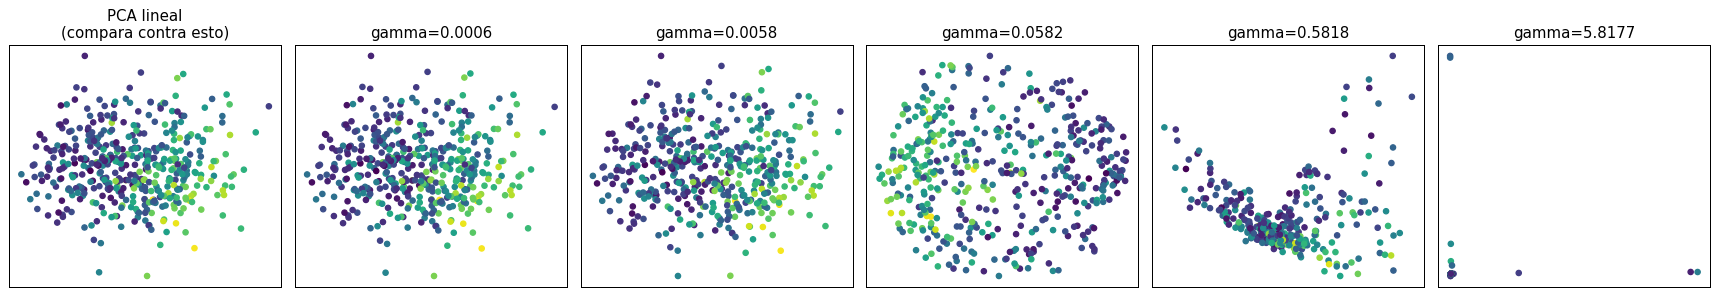

gamma chico -> se parece a PCA lineal | gamma grande -> se desarma


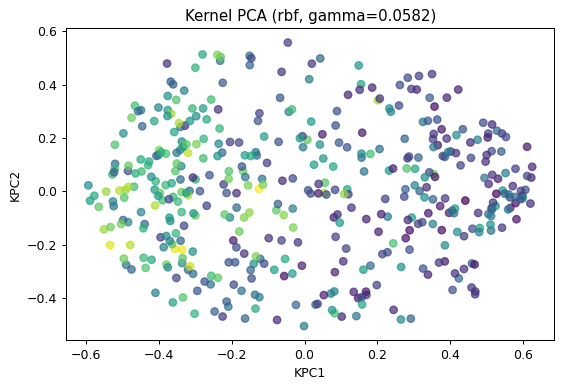

Proyección de datos nuevos: kpca.transform(X_nuevo) -> (5, 2)


In [23]:
# ═══ B11. Kernel PCA ═══
from scipy.spatial.distance import pdist as pd_

gamma_sug = 1/np.median(pd_(Xs)**2)       # heurística de la mediana
print(f"gamma sugerido por la heurística de la mediana: {gamma_sug:.4f}")

# ── Barrido de gamma: el parámetro que lo decide todo ──────────────────
gammas = [gamma_sug/100, gamma_sug/10, gamma_sug, gamma_sug*10, gamma_sug*100]
fig, axes = plt.subplots(1, len(gammas)+1, figsize=(3.2*(len(gammas)+1), 3.4))

axes[0].scatter(Z[:,0], Z[:,1], c=col, cmap="viridis", s=18)
axes[0].set_title("PCA lineal\n(compara contra esto)"); axes[0].set_xticks([]); axes[0].set_yticks([])

for a, g in zip(axes[1:], gammas):
    sc = KernelPCA(n_components=2, kernel="rbf", gamma=g).fit_transform(Xs)
    a.scatter(sc[:,0], sc[:,1], c=col, cmap="viridis", s=18)
    a.set_title(f"gamma={g:.4f}"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("gamma chico -> se parece a PCA lineal | gamma grande -> se desarma")

# ── Modelo final ───────────────────────────────────────────────────────
kpca = KernelPCA(
    n_components=2,
    kernel="rbf",          # ⬅ 'rbf' | 'poly' | 'linear' | 'sigmoid'
    gamma=gamma_sug,       # ⬅ EL parámetro crítico
).fit(Xs)
sc_kpca = kpca.transform(Xs)

plt.scatter(sc_kpca[:,0], sc_kpca[:,1], c=col, cmap="viridis", alpha=.7)
plt.xlabel("KPC1"); plt.ylabel("KPC2"); plt.title(f"Kernel PCA (rbf, gamma={gamma_sug:.4f})")
plt.show()

# KPCA SÍ puede proyectar datos nuevos (a diferencia de MDS/t-SNE)
print(f"Proyección de datos nuevos: kpca.transform(X_nuevo) -> {kpca.transform(Xs[:5]).shape}")

<a id="b12"></a>
---
# B12. SVD (Singular Value Decomposition)

## Qué hace, en simple
Descompone **cualquier** matriz (no tiene que ser cuadrada ni simétrica) en tres piezas:
$$A = U\Sigma V^\top$$

Los **valores singulares** $\sigma_1\ge\sigma_2\ge\dots$ dicen cuánta "información" hay en cada dirección. Si te quedas solo con los primeros $k$, obtienes una **versión comprimida** de la matriz.

## Eckart-Young (el teorema clave)
> Truncar a los primeros $k$ valores singulares da la **MEJOR aproximación posible de rango $k$**. Ninguna otra matriz de rango $k$ se acerca más.

Y el error se sabe **en fórmula cerrada**:
$$\|A-A_k\|_F=\sqrt{\sum_{i>k}\sigma_i^2}$$
→ los valores singulares descartados te dicen **exactamente** cuánto pierdes.

## Relación con PCA
> **PCA = SVD sobre los datos centrados.** $V$ son los componentes, $U\Sigma$ los scores, $\lambda_i=\sigma_i^2/(n-1)$.

Por eso `prcomp` y `sklearn.PCA` usan SVD: es **numéricamente más estable** que formar $X^\top X$.

## Aplicación: LSI (recuperación de información)
Matriz término-documento → SVD → espacio **semántico latente**. Resuelve la **sinonimia**: buscar "petroleum" recupera documentos que solo dicen "crude". Ranking por **similitud coseno** (no euclidiana, porque los documentos largos tendrían ventaja injusta).

## Parámetros
| Parámetro | Qué poner |
|---|---|
| `full_matrices` | **`False`** casi siempre (versión económica) |
| $k$ | Usa la **energía acumulada** $\sum_{i\le k}\sigma_i^2/\sum\sigma_i^2$ |

> ⚠️ `np.linalg.svd` devuelve **$V^\top$**; `svd()` de R devuelve $V$. Al traducir, transponer.

U: (442, 10)   S: (10,)   Vt: (10, 10)  (Vt ya está TRANSPUESTA)
valores singulares: [42.175 25.683 23.088 20.55  17.108 16.322 15.4   13.845  5.884  1.945]

Error de la descomposición: 6.22e-15

varianzas PCA      : [4.0333 1.4957 1.2087 0.9576 0.6637 0.6041 0.5378 0.4347 0.0785 0.0086]
sigma²/(n-1) de SVD: [4.0333 1.4957 1.2087 0.9576 0.6637 0.6041 0.5378 0.4347 0.0785 0.0086]   <- iguales

  k |   energía |  error real | error teórico
---------------------------------------------
  1 |    0.4024 |     51.3936 |       51.3936
  2 |    0.5517 |     44.5162 |       44.5162
  3 |    0.6722 |     38.0612 |       38.0612
  4 |    0.7678 |     32.0365 |       32.0365
  5 |    0.8340 |     27.0860 |       27.0860
  6 |    0.8943 |     21.6160 |       21.6160
Los valores singulares descartados dicen EXACTAMENTE cuánto se pierde.


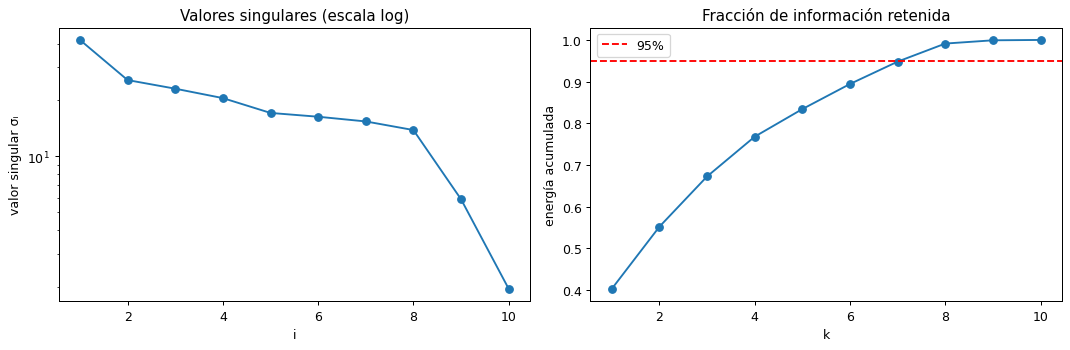

In [24]:
# ═══ B12. SVD ═══
Xc = Xs - Xs.mean(0)                              # datos centrados
U, S, Vt = np.linalg.svd(Xc, full_matrices=False) # ⬅ False = versión económica

print(f"U: {U.shape}   S: {S.shape}   Vt: {Vt.shape}  (Vt ya está TRANSPUESTA)")
print(f"valores singulares: {np.round(S,3)}")
print(f"\nError de la descomposición: {np.abs(Xc - U@np.diag(S)@Vt).max():.2e}")

# ── SVD == PCA ─────────────────────────────────────────────────────────
print(f"\nvarianzas PCA      : {np.round(pca.explained_variance_,4)}")
print(f"sigma²/(n-1) de SVD: {np.round(S**2/(len(Xs)-1),4)}   <- iguales")

# ── Eckart-Young: el error se sabe en fórmula cerrada ─────────────────
energia = np.cumsum(S**2)/np.sum(S**2)
print(f"\n{'k':>3} | {'energía':>9} | {'error real':>11} | {'error teórico':>13}")
print("-"*45)
for k in range(1, min(6, len(S))+1):
    Ak = U[:,:k]@np.diag(S[:k])@Vt[:k,:]
    print(f"{k:3d} | {energia[k-1]:9.4f} | {np.linalg.norm(Xc-Ak,'fro'):11.4f} | "
          f"{np.sqrt(np.sum(S[k:]**2)):13.4f}")
print("Los valores singulares descartados dicen EXACTAMENTE cuánto se pierde.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1,len(S)+1), S, "o-"); ax[0].set_yscale("log")
ax[0].set_xlabel("i"); ax[0].set_ylabel("valor singular σᵢ")
ax[0].set_title("Valores singulares (escala log)")
ax[1].plot(range(1,len(S)+1), energia, "o-")
ax[1].axhline(.95, color="red", ls="--", label="95%")
ax[1].set_xlabel("k"); ax[1].set_ylabel("energía acumulada")
ax[1].set_title("Fracción de información retenida"); ax[1].legend()
plt.tight_layout(); plt.show()

<a id="b13"></a>
---
# B13. Manifold Learning: Isomap, LLE y t-SNE

## La idea, en simple
A veces los datos viven sobre una **superficie doblada** dentro del espacio. Imagina una hoja de papel enrollada en 3D: en realidad es 2D, solo está torcida.

PCA la **aplasta** y pone juntos puntos que sobre la hoja están lejísimos. Estos métodos la **desenrollan**.

La clave: distinguir la distancia **en línea recta** (a través del aire) de la distancia **caminando sobre la superficie** (geodésica).

## Isomap
= **MDS con distancias geodésicas**. Construye un grafo de $k$ vecinos, calcula caminos más cortos sobre el grafo (eso aproxima la geodésica) y aplica MDS.

✅ Preserva estructura **global** · solución cerrada
❌ **Muy sensible a k**: k grande → crea **"atajos"** que saltan de un pliegue a otro y destruyen todo; k chico → el grafo se desconecta · $O(n^3)$

## LLE
Preserva **relaciones lineales locales**: los pesos con que cada punto se reconstruye desde sus vecinos deben seguir valiendo en el mapa nuevo.
Variantes: `standard` · `modified` · `hessian` · **`ltsa`** (suele dar lo mejor)

❌ No preserva distancias globales · tiende a **colapsar regiones**

## t-SNE
Convierte distancias en **probabilidades** y minimiza la divergencia KL. Usa una **t de Student** en baja dimensión (colas pesadas) para dar espacio entre clusters.

### ⚠️ Lo que NO se puede leer de un t-SNE (esto lo preguntan)
- **Los tamaños de los clusters no significan nada**
- **Las distancias ENTRE clusters no significan nada**
- Puede **inventar clusters** en datos sin estructura
- **No es determinista** · **no proyecta datos nuevos**

## Parámetros
| Método | Parámetro | Qué poner |
|---|---|---|
| Isomap | `n_neighbors` | **El crítico.** 5–15 típico |
| LLE | `n_neighbors`, `method` | `'ltsa'` suele ser la mejor variante |
| t-SNE | **`perplexity`** | **5–50.** Baja → grumos falsos; alta → se aplana |
| t-SNE | `init` | `'pca'` es más estable que `'random'` |

## ⚠️ EL CONTROL OBLIGATORIO
**Estos métodos SIEMPRE dibujan algo bonito, incluso con ruido puro.** Antes de interpretar, corre el mismo método sobre datos permutados y compara. El código lo hace.

LLE: funcionó con method='ltsa'


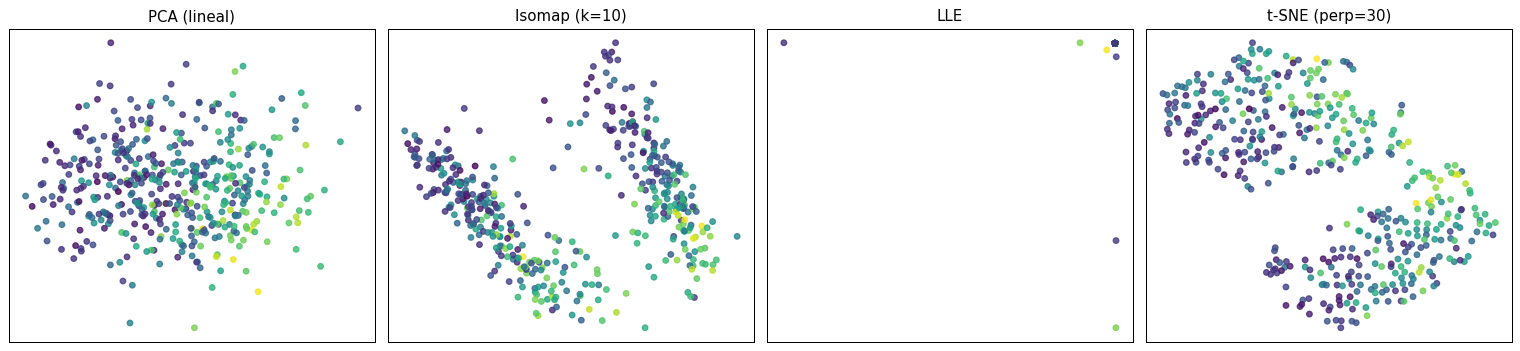

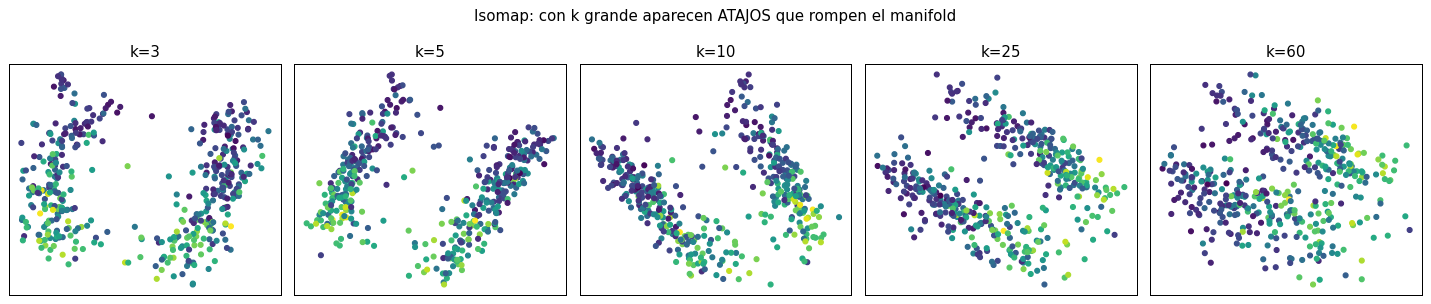

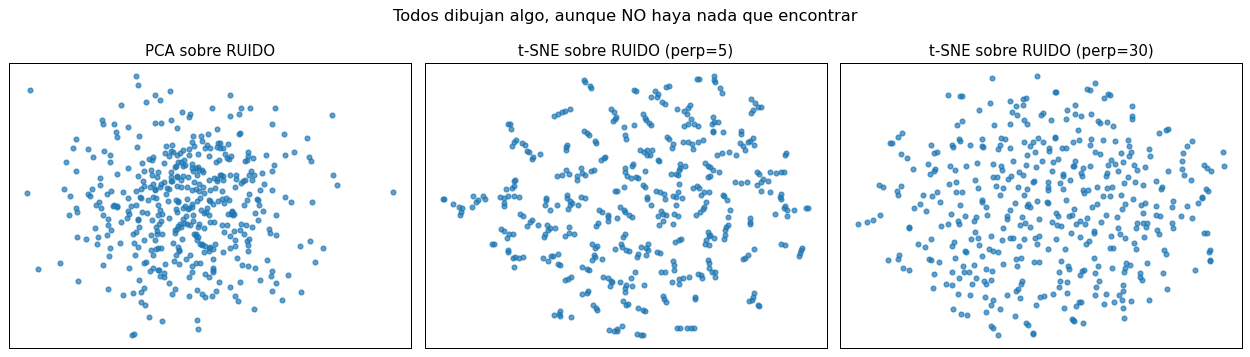

Con perplexity baja, t-SNE fabrica grumos convincentes sobre ruido puro.
MORALEJA: un gráfico bonito NO es evidencia de estructura.


In [25]:
# ═══ B13. Manifold Learning ═══

K_VEC = min(10, len(Xs)-1)       # ⬅ n_neighbors: el parámetro crítico
PERP  = min(30, (len(Xs)-1)//3)  # ⬅ perplexity de t-SNE (5-50)

emb_pca  = Z[:, :2]
emb_iso  = manifold.Isomap(n_neighbors=K_VEC, n_components=2).fit_transform(Xs)
# LLE es numéricamente delicado: si 'ltsa' falla, se prueban las otras
# variantes. 'hessian' es la más frágil de todas.
emb_lle = None
for metodo in ["ltsa", "modified", "standard"]:          # ⬅ variantes de LLE
    try:
        emb_lle = manifold.LocallyLinearEmbedding(
            n_neighbors=K_VEC, n_components=2,
            method=metodo, eigen_solver="dense",         # 'dense' es más estable
            random_state=0).fit_transform(Xs)
        print(f"LLE: funcionó con method='{metodo}'")
        break
    except Exception as e:
        print(f"LLE: method='{metodo}' falló ({type(e).__name__})")
if emb_lle is None:
    emb_lle = Z[:, :2]
    print("LLE falló con todas las variantes; se muestra PCA en su lugar.")
emb_tsne = manifold.TSNE(n_components=2, perplexity=PERP, init="pca",
                         random_state=0).fit_transform(Xs)

fig, ax = plt.subplots(1, 4, figsize=(17, 4))
for a,(e,t) in zip(ax, [(emb_pca,"PCA (lineal)"), (emb_iso,f"Isomap (k={K_VEC})"),
                        (emb_lle,"LLE"), (emb_tsne,f"t-SNE (perp={PERP})")]):
    a.scatter(e[:,0], e[:,1], c=col, cmap="viridis", s=20, alpha=.8)
    a.set_title(t); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

# ── Sensibilidad a k en Isomap ─────────────────────────────────────────
ks_try = [3, 5, 10, 25, min(60, len(Xs)-1)]
fig, ax = plt.subplots(1, len(ks_try), figsize=(3.2*len(ks_try), 3.4))
for a, kk in zip(ax, ks_try):
    try:
        e = manifold.Isomap(n_neighbors=kk, n_components=2).fit_transform(Xs)
        a.scatter(e[:,0], e[:,1], c=col, cmap="viridis", s=15)
        a.set_title(f"k={kk}")
    except Exception:
        a.set_title(f"k={kk}: falla\n(grafo desconectado)")
    a.set_xticks([]); a.set_yticks([])
fig.suptitle("Isomap: con k grande aparecen ATAJOS que rompen el manifold")
plt.tight_layout(); plt.show()

# ── ⚠️ EL CONTROL: ¿qué sale con datos SIN estructura? ────────────────
ruido = np.random.default_rng(0).standard_normal(Xs.shape)   # ruido puro
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(*PCA(n_components=2).fit_transform(ruido).T, s=15, alpha=.7)
ax[0].set_title("PCA sobre RUIDO")
for i, pp in enumerate([5, PERP]):
    e = manifold.TSNE(n_components=2, perplexity=pp, init="random",
                      random_state=0).fit_transform(ruido)
    ax[i+1].scatter(*e.T, s=15, alpha=.7)
    ax[i+1].set_title(f"t-SNE sobre RUIDO (perp={pp})")
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.suptitle("Todos dibujan algo, aunque NO haya nada que encontrar", fontsize=13)
plt.tight_layout(); plt.show()
print("Con perplexity baja, t-SNE fabrica grumos convincentes sobre ruido puro.")
print("MORALEJA: un gráfico bonito NO es evidencia de estructura.")

<a id="final"></a>
---
# 🎯 TABLA FINAL — qué método usar

## Si tienes variable respuesta `y` (SUPERVISADO)

| Situación | Método | Sección |
|---|---|---|
| Punto de partida siempre | Regresión lineal | [A7](#a7) |
| Relación no lineal, pocas variables | KNN / kernel regression | [A3](#a3) |
| Muchas variables correlacionadas | **Ridge** | [A9](#a9) |
| Muchas variables, pocas importan | **Lasso** (da ceros) | [A9](#a9) |
| Correlación **y** quieres selección | **Elastic Net** | [A9](#a9) |
| $p$ pequeño, quieres el mejor subconjunto | Exhaustivo | [A8](#a8) |
| $p$ grande, quieres seleccionar rápido | Forward | [A8](#a8) |
| Comparar modelos sin partir la muestra | AIC / BIC / Cp / R²adj | [A5](#a5) |
| Calibrar cualquier parámetro | Validación cruzada | [A6](#a6) |

## Si NO tienes `y` (NO SUPERVISADO)

| Situación | Método | Sección |
|---|---|---|
| Agrupar, clusters redondos, n grande | K-Means | [B1](#b1) |
| Agrupar con outliers o categóricas | K-Medoides + Gower | [B2](#b2) |
| Ver la jerarquía, no fijar K | Jerárquico | [B3](#b3) |
| Clusters de forma rara + detectar ruido | DBSCAN | [B4](#b4) |
| Elegir K | Codo / Silhouette | [B5](#b5) |
| Outliers, pocas variables | Mahalanobis | [B6](#b6) |
| Outliers, muchas variables | Isolation Forest | [B7](#b7) |
| Outliers locales / densidades distintas | LOF | [B7](#b7) |
| Reducir dimensión, visualizar | PCA | [B8](#b8) |
| Solo tengo distancias | MDS | [B9](#b9) |
| Buscar factores latentes interpretables | Análisis Factorial | [B10](#b10) |
| Estructura no lineal + proyectar datos nuevos | Kernel PCA | [B11](#b11) |
| Comprimir una matriz / LSI | SVD | [B12](#b12) |
| Solo visualizar estructura curva | Isomap / t-SNE | [B13](#b13) |

---

# ⚠️ LAS 15 TRAMPAS DEL CURSO

| # | Trampa |
|---|---|
| 1 | **El MSE de train siempre baja** con más flexibilidad. Calibra SIEMPRE con test o CV |
| 2 | **La curva del MSE de test tiene forma de U.** El óptimo es el mínimo |
| 3 | **En KNN, Ridge y kernel el parámetro GRANDE = modelo RÍGIDO** (al revés de lo intuitivo) |
| 4 | **BIC castiga más que AIC** ($p\log n$ vs. $2p$) ⇒ BIC elige modelos más pequeños |
| 5 | **Accuracy engaña con clases desbalanceadas.** Mira la matriz de confusión |
| 6 | **Lasso da ceros exactos (selecciona); Ridge nunca.** La diferencia clave |
| 7 | **Hay que estandarizar** en KNN, Ridge/Lasso, K-Means, PCA, DBSCAN… todo lo que use distancias |
| 8 | **Forward NO garantiza el mejor modelo** (es heurística); el exhaustivo sí, pero es $2^p-1$ |
| 9 | **K-Means siempre devuelve K grupos**, aunque no haya estructura |
| 10 | **Silhouette/CH/DB premian a K-Means sobre DBSCAN en anillos.** Asumen clusters redondos |
| 11 | **El Z-Score se enmascara** con grupos de outliers. Usa el Z modificado (mediana+MAD) |
| 12 | **Mirar variable por variable ≠ Mahalanobis** (un punto puede romper la correlación) |
| 13 | **p-valor ALTO en análisis factorial = modelo ADECUADO** (al revés de lo habitual) |
| 14 | **En t-SNE, tamaños y distancias entre clusters no significan nada** |
| 15 | **Manifold learning siempre dibuja algo bonito**, aunque sea ruido puro |

# 🔗 EQUIVALENCIAS QUE PREGUNTAN

- **MDS clásico (euclidiano) = PCA**
- **PCA = SVD sobre datos centrados**
- **Isomap = MDS con distancias geodésicas**
- **Kernel PCA con kernel lineal = PCA**
- **min WSS = max BSS** (identidad ANOVA, solo K-Means euclidiano)
- **Elastic Net con $\alpha=0$ = Ridge; con $\alpha=1$ = Lasso**